# Models' Architectures Exploration

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch

### Plot and analysis utilities

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from collections import defaultdict

# ── Palette e stile ───────────────────────────────────────────────────────────
C_WIKI  = "#4878CF"
C_RAND  = "#D65F5F"
C_MODEL = "#2CA02C"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#333", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#CCCCCC", "grid.linewidth": 0.5,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.titlesize": 9, "axes.titleweight": "bold", "axes.titlepad": 6,
    "font.family": "DejaVu Sans",
})

PTYPE_WIKI      = "wikitext_wikitext-103-raw-v1_train"
PTYPE_RAND      = "random_vocab"
N_COLS          = 3
STRIP_THRESHOLD = 80
RANK_PADDING    = 5
SAVE_PLOTS      = False
out_dir         = Path("output"); out_dir.mkdir(exist_ok=True)

# ── Registro tassonomico ──────────────────────────────────────────────────────
TAXONOMY = {

    "model_dependent": {

        "Weight Matrix Ranks Wq": {
            "features":    ["effective_rank_Wq", "r95_Wq"],
            "bounds":      {},
            "rank_max":    128,
            "use_logy":    False, "use_density": True,
            "show_split":  False,
            "notes": "Per-head slice of W_q. 32 distinct heads in Mistral-7B.",
        },

        "Weight Matrix Ranks Wk Wv": {
            "features":    ["effective_rank_Wk","r95_Wk","effective_rank_Wv","r95_Wv"],
            "bounds":      {},
            "rank_max":    128,
            "use_logy":    False, "use_density": True,
            "show_split":  False,
            "notes": "Per-KV-head slice of W_k/W_v. 8 distinct KV-heads in Mistral-7B (GQA).",
        },

        "Gini Spectral Concentration": {
            "features":    ["gini_left_Wq","gini_right_Wq","gini_left_Wk","gini_right_Wk"],
            "bounds":      {f:(0.0,1.0) for f in
                            ["gini_left_Wq","gini_right_Wq","gini_left_Wk","gini_right_Wk"]},
            "use_logy":    False, "use_density": True,
            "show_split":  False,
            "notes": "Gini over left/right singular vectors of W_q/W_k. In [0,1].",
        },

        "RMSNorm": {
            "features":    ["rmsnorm_gamma_norm"],
            "bounds":      {"rmsnorm_gamma_norm":(0.0, None)},
            "use_logy":    False, "use_density": True,
            "show_split":  False,
            "notes": "L2 norm of RMSNorm gamma. Fixed per layer.",
        },

        "RoPE Structure": {
            "features":    ["rope_pair_var_Wq","rope_pair_var_Wk",
                            "rope_pair_max_ratio_Wq","rope_pair_max_ratio_Wk",
                            "rope_freq_com_Wq","rope_freq_com_Wk"],
            "bounds":      {"rope_pair_var_Wq":(0,None),"rope_pair_var_Wk":(0,None),
                            "rope_pair_max_ratio_Wq":(0,None),"rope_pair_max_ratio_Wk":(0,None),
                            "rope_freq_com_Wq":(0,63.0),"rope_freq_com_Wk":(0,63.0)},
            "use_logy":    False, "use_density": True,
            "show_split":  False,
            "notes": "rope_freq_com in [0,63]. rope_pair_max_ratio: dominance of top RoPE pair.",
        },

        "RoPE-aware QK Alignment": {
            "features":    ["compute_WqRWk_alignment_delta_0"],
            "bounds":      {"compute_WqRWk_alignment_delta_0":(0,1)},
            "use_logy":    False, "use_density": True,
            "show_split":  False,
            "notes": "Cosine alignment W_q * R(delta=0) * W_k^T. Pure weight property.",
        },

        "SVD Alignment H vs W": {
            "features":    ["svd_alignment_H_Wq","svd_alignment_H_Wk"],
            "bounds":      {"svd_alignment_H_Wq":(0,1),"svd_alignment_H_Wk":(0,1)},
            "use_logy":    False, "use_density": True,
            "show_split":  True,
            "notes": "Cosine sim top singular vector of H vs W_q/W_k. Mixed: W fixed, H input-dep.",
        },
    },

    "input_dependent": {

        "Hidden State Rank": {
            "features":    ["effective_rank_H","r95_H"],
            "bounds":      {},
            "rank_max":    512,
            "use_logy":    False, "use_density": True,
            "show_split":  True,
            "notes": "H shape (seq_len, 4096). rank_max=min(seq_len,4096).",
        },

        "Projected Q/K Ranks": {
            "features":    ["effective_rank_Q","r95_Q","effective_rank_K","r95_K"],
            "bounds":      {},
            "rank_max":    128,
            "use_logy":    True, "use_density": True,
            "show_split":  True,
            "notes": "Q=H*W_q^T, K=H*W_k^T per head. Shape (seq,128).",
        },

        "Temporal Similarity": {
            "features":    ["q_sim_consecutive","k_sim_consecutive"],
            "bounds":      {"q_sim_consecutive":(0,1),"k_sim_consecutive":(0,1)},
            "use_logy":    False, "use_density": True,
            "show_split":  True,
            "notes": "Mean cosine sim between consecutive token rows of Q/K.",
        },
    },

    "target": {

        "Attention Map Diagonal Mass": {
            "features":    ["diagonal_mass_1","diagonal_mass_5",
                            "diagonal_mass_1_shifted_1","diagonal_mass_1_shifted_2",
                            "diagonal_mass_1_shifted_3","diagonal_mass_1_shifted_4"],
            "bounds":      {f:(0,1) for f in
                            ["diagonal_mass_1","diagonal_mass_5","diagonal_mass_1_shifted_1",
                             "diagonal_mass_1_shifted_2","diagonal_mass_1_shifted_3",
                             "diagonal_mass_1_shifted_4"]},
            "use_logy":    True, "use_density": True,
            "show_split":  True,
            "notes": "Attention mass on main diagonal (width 1 or 5) and sub-diagonals.",
        },

        "Attention Map Sink Mass": {
            "features":    ["sink_mass_token_0","sink_mass_token_1","sink_mass_token_2",
                            "sink_mass_token_3","sink_mass_token_4","sink_mass_max"],
            "bounds":      {f:(0,1) for f in
                            ["sink_mass_token_0","sink_mass_token_1","sink_mass_token_2",
                             "sink_mass_token_3","sink_mass_token_4","sink_mass_max"]},
            "use_logy":    True, "use_density": True,
            "show_split":  True,
            "notes": "Attention mass on first 5 tokens (sinks). sink_mass_max = row-wise max.",
        },

        "Attention Map Structure": {
            "features":    ["look_back","attention_gini"],
            "bounds":      {"look_back":(0,1),"attention_gini":(0,1)},
            "use_logy":    False, "use_density": True,
            "show_split":  True,
            "notes": "look_back: mean backward distance norm. attention_gini: row Gini.",
        },

        "Attention Matrix Rank": {
            "features":    ["effective_rank_A","r95_A"],
            "bounds":      {},
            "rank_max":    512,
            "use_logy":    False, "use_density": True,
            "show_split":  True,
            "notes": "Rank of post-softmax A. Low=sparse, High=diffuse.",
        },
    },
}

# ── Mappa dedup per singola feature ──────────────────────────────────────────
FEATURE_DEDUP = {
    "effective_rank_Wq":               ["layer_idx", "head_idx"],
    "r95_Wq":                          ["layer_idx", "head_idx"],
    "gini_left_Wq":                    ["layer_idx", "head_idx"],
    "gini_right_Wq":                   ["layer_idx", "head_idx"],
    "rope_pair_var_Wq":                ["layer_idx", "head_idx"],
    "rope_pair_max_ratio_Wq":          ["layer_idx", "head_idx"],
    "rope_freq_com_Wq":                ["layer_idx", "head_idx"],
    "compute_WqRWk_alignment_delta_0": ["layer_idx", "head_idx"],

    "effective_rank_Wk":               ["layer_idx", "kv_head"],
    "r95_Wk":                          ["layer_idx", "kv_head"],
    "effective_rank_Wv":               ["layer_idx", "kv_head"],
    "r95_Wv":                          ["layer_idx", "kv_head"],
    "gini_left_Wk":                    ["layer_idx", "kv_head"],
    "gini_right_Wk":                   ["layer_idx", "kv_head"],
    "rope_pair_var_Wk":                ["layer_idx", "kv_head"],
    "rope_pair_max_ratio_Wk":          ["layer_idx", "kv_head"],
    "rope_freq_com_Wk":                ["layer_idx", "kv_head"],

    "rmsnorm_gamma_norm":              ["layer_idx"],
}

# ── Helper: deduplicazione + split ───────────────────────────────────────────
def _prepare_vals(df, feat, show_split):
    dedup_cols = FEATURE_DEDUP.get(feat, None)

    if dedup_cols is not None:
        if "kv_head" in dedup_cols and "kv_head" not in df.columns:
            df = df.copy()
            df["kv_head"] = df["head_idx"] // 4
        subset = [c for c in dedup_cols if c in df.columns]
        sub = df.drop_duplicates(subset=subset) if subset else df
    else:
        sub = df

    if show_split:
        return {
            "wikitext": sub[sub["prompt_source"] == PTYPE_WIKI][feat].dropna().values,
            "random":   sub[sub["prompt_source"] == PTYPE_RAND][feat].dropna().values,
        }
    else:
        return {"all": sub[feat].dropna().values}

# ── Raggruppamento per suffisso: effective_rank_X e r95_X → stesso range ─────
def _group_rank_features_by_suffix(features):
    """
    Raggruppa le feature di rango per suffisso comune.
    effective_rank_X e r95_X condividono il range; X≠Y hanno range indipendenti.
    Feature senza prefisso riconosciuto → gruppo isolato (chiave = nome feature).
    """
    groups = defaultdict(list)
    for f in features:
        matched = False
        for prefix in ("effective_rank_", "r95_"):
            if f.startswith(prefix):
                groups[f[len(prefix):]].append(f)
                matched = True
                break
        if not matched:
            groups[f].append(f)
    return dict(groups)   # {suffix: [feat1, feat2, ...]}

# ── Bound dinamici per ranghi ─────────────────────────────────────────────────
def _compute_rank_bounds(vals_list, rank_max, padding=RANK_PADDING):
    """
    [lo, hi] condiviso su vals_list.
    - padding simmetrico intero
    - clipping a [1, rank_max]; se rank_max is None: solo lower clip a 1
    """
    all_v = np.concatenate([v for v in vals_list if len(v)])
    if len(all_v) == 0:
        return 1, (rank_max if rank_max is not None else 1)

    lo = max(1, int(np.floor(all_v.min())) - padding)
    hi = int(np.ceil(all_v.max())) + padding
    if rank_max is not None:
        hi = min(hi, rank_max)
    return lo, hi

# ── Calcolo feat_bounds (comune a hist e strip) ───────────────────────────────
def _build_feat_bounds(valid, meta, df):
    bounds     = meta["bounds"]
    show_split = meta["show_split"]
    feat_bounds = {}

    if "rank_max" in meta:
        rank_max      = meta["rank_max"]
        suffix_groups = _group_rank_features_by_suffix(valid)
        for suffix, suffix_feats in suffix_groups.items():
            group_vals = []
            for f in suffix_feats:
                sv = _prepare_vals(df, f, show_split)
                group_vals.extend(v for v in sv.values() if len(v))
            lo_p, hi_p = _compute_rank_bounds(group_vals, rank_max)
            for f in suffix_feats:
                feat_bounds[f] = (lo_p, hi_p)
    else:
        for f in valid:
            sv    = _prepare_vals(df, f, show_split)
            all_v = np.concatenate(list(sv.values()))

            if len(all_v) == 0:          # ← guard: feature presente in df ma senza valori
                feat_bounds[f] = (0.0, 1.0)   # fallback neutro
                continue

            lo, hi = bounds.get(f, (None, None))
            lo_p   = lo if lo is not None else float(all_v.min()) - abs(float(all_v.min())) * 0.02
            hi_p   = hi if hi is not None else float(all_v.max()) * 1.02
            feat_bounds[f] = (lo_p, hi_p)

    return feat_bounds

# ── Bin automatici ────────────────────────────────────────────────────────────
def _compute_bins(vals_list, lo_p, hi_p, min_bins=10, max_bins=150):
    all_v = np.concatenate([np.clip(v, lo_p, hi_p) for v in vals_list if len(v)])
    n     = len(all_v)
    r     = hi_p - lo_p   # range effettivo

    if n < 4 or r == 0:
        return np.linspace(lo_p, hi_p, min_bins + 1)

    # ── Tre stimatori ────────────────────────────────────────────────────────
    iqr = np.percentile(all_v, 75) - np.percentile(all_v, 25)
    std = np.std(all_v)

    # Freedman-Diaconis: ottimo per distribuzioni asimmetriche/heavy-tail
    n_fd = int(np.ceil(r / (2.0 * iqr * n**(-1/3)))) if iqr > 0 else max_bins

    # Scott: ottimo per distribuzioni unimodali normali
    n_sc = int(np.ceil(r / (3.49 * std * n**(-1/3)))) if std > 0 else max_bins

    # Sturges: conservativo, buono per n piccolo
    n_st = int(np.ceil(np.log2(n) + 1))

    # ── Caso degenere: distribuzione quasi-costante ──────────────────────────
    # Se IQR è molto piccolo rispetto al range, FD esplode → usa Scott o Sturges
    if iqr > 0 and (r / iqr) > 50:
        # distribuzione molto concentrata: FD inaffidabile, usa Scott
        n_bins = max(n_sc, n_st)
    elif iqr == 0:
        # tutti i valori uguali o quasi: usa sqrt(n) come euristica robusta
        n_bins = max(int(np.sqrt(n)), n_st)
    else:
        # caso normale: mediana tra i tre (robusta agli outlier dei singoli stimatori)
        n_bins = int(np.median([n_fd, n_sc, n_st]))

    return np.linspace(lo_p, hi_p, int(np.clip(n_bins, min_bins, max_bins)) + 1)

# ── Selezione automatica del tipo di plot ─────────────────────────────────────
def _choose_plot_type(df, meta):
    for feat in meta["features"]:
        if feat in df.columns:
            n = sum(len(v) for v in _prepare_vals(df, feat, meta["show_split"]).values())
            return "strip" if n < STRIP_THRESHOLD else "hist"
    return "hist"

# ── Plot: istogramma ──────────────────────────────────────────────────────────
def _plot_hist(group_name, meta, df):
    from IPython.display import display

    features   = meta["features"]
    use_logy   = meta["use_logy"]
    use_density = meta["use_density"]
    show_split  = meta["show_split"]

    valid   = [f for f in features if f in df.columns]
    missing = [f for f in features if f not in df.columns]
    if missing:
        print(f"  [SKIP] {group_name}: {missing}")
    if not valid:
        return

    feat_bounds = _build_feat_bounds(valid, meta, df)   # ← unica chiamata

    n_cols = min(N_COLS, len(valid))
    n_rows = int(np.ceil(len(valid) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5*n_cols, 3.6*n_rows), constrained_layout=True)
    axes = np.array(axes).reshape(n_rows, n_cols)

    palette      = {"wikitext": C_WIKI, "random": C_RAND, "all": C_MODEL}
    labels       = {"wikitext": "Wikitext", "random": "Random", "all": "all heads"}
    legend_drawn = False

    for idx, feat in enumerate(valid):
        row, col   = divmod(idx, n_cols)
        ax         = axes[row, col]
        split_vals = _prepare_vals(df, feat, show_split)
        all_v      = np.concatenate(list(split_vals.values()))

        if len(all_v) == 0:
            ax.set_visible(False)
            continue

        lo_p, hi_p = feat_bounds[feat]   # ← lookup diretto, sempre valido
        bins = _compute_bins(list(split_vals.values()), lo_p, hi_p,
                             min_bins=meta.get("min_bins", 10),
                             max_bins=meta.get("max_bins", 150))

        for key, vals in split_vals.items():
            vc = np.clip(vals, lo_p, hi_p)
            ax.hist(vc, bins=bins, color=palette[key], alpha=0.65,
                    label=labels[key], density=use_density)
            if len(vc):
                ax.axvline(np.mean(vc),   color=palette[key], lw=1.4, ls="-")
                ax.axvline(np.median(vc), color=palette[key], lw=1.4, ls="--")

        ax.set_xlim(lo_p, hi_p)
        if use_logy:
            ax.set_yscale("log")
        ax.set_ylabel(("density" if use_density else "count") if col == 0 else "")
        ax.set_title(feat.replace("_", " "), pad=4)

        if not legend_drawn:
            ax.legend(title="— mean   -- median",
                      title_fontsize=7, loc="upper right", fontsize=7)
            legend_drawn = True

    for idx in range(len(valid), n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].set_visible(False)

    tags      = ("  [log y]" if use_logy else "") + ("  [density]" if use_density else "  [count]")
    split_tag = "  [Wikitext vs Random]" if show_split else "  [model only]"
    fig.suptitle(f"{group_name}{tags}{split_tag}  [hist]",
                 fontsize=10, fontweight="bold", y=1.01)

    if SAVE_PLOTS:
        _save_fig(fig, f"hist_{group_name}")
    display(fig)
    plt.close(fig)

# ── Plot: strip + box ─────────────────────────────────────────────────────────
def _plot_strip(group_name, meta, df):
    from IPython.display import display

    features   = meta["features"]
    use_logy   = meta["use_logy"]
    show_split = meta["show_split"]

    valid   = [f for f in features if f in df.columns]
    missing = [f for f in features if f not in df.columns]
    if missing:
        print(f"  [SKIP] {group_name}: {missing}")
    if not valid:
        return

    feat_bounds = _build_feat_bounds(valid, meta, df)   # ← unica chiamata

    n_cols = min(N_COLS, len(valid))
    n_rows = int(np.ceil(len(valid) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4.5*n_cols, 3.2*n_rows), constrained_layout=True)
    axes = np.array(axes).reshape(n_rows, n_cols)

    palette = {"wikitext": C_WIKI, "random": C_RAND, "all": C_MODEL}
    labels  = {"wikitext": "Wikitext", "random": "Random", "all": "all heads"}
    rng     = np.random.default_rng(42)

    for idx, feat in enumerate(valid):
        row, col   = divmod(idx, n_cols)
        ax         = axes[row, col]
        split_vals = _prepare_vals(df, feat, show_split)
        all_v      = np.concatenate(list(split_vals.values()))

        if len(all_v) == 0:
            ax.set_visible(False)
            continue

        lo_p, hi_p = feat_bounds[feat]   # ← lookup diretto, sempre valido
        box_data, box_pos, box_colors = [], [], []

        for i, (key, vals) in enumerate(split_vals.items()):
            if len(vals) == 0:
                continue
            color  = palette[key]
            jitter = rng.uniform(-0.18, 0.18, size=len(vals))
            ax.scatter(np.full(len(vals), i) + jitter, vals,
                       color=color, alpha=0.7, s=22, linewidths=0,
                       label=labels[key], zorder=3)
            ax.hlines(np.mean(vals),   i - 0.3, i + 0.3,
                      color=color, lw=2.0, ls="-",  zorder=4)
            ax.hlines(np.median(vals), i - 0.3, i + 0.3,
                      color=color, lw=2.0, ls="--", zorder=4)
            box_data.append(vals)
            box_pos.append(i)
            box_colors.append(color)

        if box_data:
            bp = ax.boxplot(box_data, positions=box_pos, widths=0.35,
                            patch_artist=True, showfliers=False, zorder=2,
                            medianprops=dict(linewidth=0),
                            whiskerprops=dict(linewidth=0.8, color="#888"),
                            capprops=dict(linewidth=0.8, color="#888"),
                            boxprops=dict(linewidth=0.8))
            for patch, color in zip(bp["boxes"], box_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.15)

        keys = list(split_vals.keys())
        ax.set_xticks(range(len(keys)))
        ax.set_xticklabels([labels[k] for k in keys], fontsize=8)
        ax.set_ylim(lo_p, hi_p)
        if use_logy:
            ax.set_yscale("log")
        ax.set_ylabel(feat.replace("_", " ") if col == 0 else "")
        ax.set_title(feat.replace("_", " "), pad=4)

        if idx == 0:
            handles = [
                Line2D([0],[0], color="gray", lw=2, ls="-",  label="mean"),
                Line2D([0],[0], color="gray", lw=2, ls="--", label="median"),
            ]
            ax.legend(handles=handles, fontsize=7, loc="upper right")

    for idx in range(len(valid), n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].set_visible(False)

    split_tag = "  [Wikitext vs Random]" if show_split else "  [model only — per head]"
    fig.suptitle(f"{group_name}{split_tag}  [strip+box]",
                 fontsize=10, fontweight="bold", y=1.01)

    if SAVE_PLOTS:
        _save_fig(fig, f"strip_{group_name}")
    display(fig)
    plt.close(fig)

# ── Save helper ───────────────────────────────────────────────────────────────
def _save_fig(fig, name):
    safe = (name.lower()
            .replace(" ","_").replace("(","").replace(")","").replace(",","")
            .replace("/","_").replace("—","").replace("&","")
            .replace("__","_").strip("_"))
    fig.savefig(out_dir / f"{safe}.png", dpi=150, bbox_inches="tight")

# ── Entry point unificato ─────────────────────────────────────────────────────
def plot_group(group_name, meta, df):
    plot_type = _choose_plot_type(df, meta)
    if plot_type == "strip":
        _plot_strip(group_name, meta, df)
    else:
        _plot_hist(group_name, meta, df)



## Mistral-7B-Instruct-v0.3 

### Embdedding space analysis

Exploration of cosine similarities between every pair of tokens to visualize anisotropy

In [100]:
# Plot of the cos sim

### Univariate analysis of features in the dataset built

In [101]:
df = pd.read_parquet('Mistral_512tok.parquet')
#df = pd.read_parquet('Qwen3_4B_512tok.parquet')

df.head()


model_name  \
run_idx                                            sub_idx                                       
mistralai/Mistral-7B-Instruct-v0.3::random_voca... 0        mistralai/Mistral-7B-Instruct-v0.3   
                                                   1        mistralai/Mistral-7B-Instruct-v0.3   
                                                   2        mistralai/Mistral-7B-Instruct-v0.3   
                                                   3        mistralai/Mistral-7B-Instruct-v0.3   
                                                   4        mistralai/Mistral-7B-Instruct-v0.3   

                                                            layer_idx  \
run_idx                                            sub_idx              
mistralai/Mistral-7B-Instruct-v0.3::random_voca... 0                0   
                                                   1                0   
                                                   2                0   
                                                   3                0   
                                                   4                0   

                                                            head_idx  \
run_idx                                            sub_idx             
mistralai/Mistral-7B-Instruct-v0.3::random_voca... 0               0   
                                                   1               1   
                                                   2               2   
                                                   3               3   
                                                   4               4   

                                                            prompt_len  \
run_idx                                            sub_idx               
mistralai/Mistral-7B-Instruct-v0.3::random_voca... 0               512   
                                                   1               512   
                                                   2               512   
                                                   3               512   
                                                   4               512   

                                                           prompt_source  \
run_idx                                            sub_idx                 
mistralai/Mistral-7B-Instruct-v0.3::random_voca... 0        random_vocab   
                                                   1        random_vocab   
                                                   2        random_vocab   
                                                   3        random_vocab   
                                                   4        random_vocab   

                                                            effective_rank_Wq  \
run_idx                                            sub_idx                      
mistralai/Mistral-7B-Instruct-v0.3::random_voca... 0                31.393360   
                                                   1                34.844074   
                                                   2                35.192970   
                                                   3                28.376795   
                                                   4                28.151308   

                                                            r95_Wq  \
run_idx                                            sub_idx           
mistralai/Mistral-7B-Instruct-v0.3::random_voca... 0          71.0   
                                                   1          76.0   
                                                   2          67.0   
                                                   3          58.0   
                                                   4          71.0   

                                                            effective_rank_Wk  \
run_idx                                            sub_idx                      
mistralai/Mistral-7B-Instruct-v0.3::random_voca... 0                38.891537   
                          

#### Architecture dependent features

SCRIPT 1 — MODEL-DEPENDENT FEATURES

[Weight Matrix Ranks Wq] Per-head slice of W_q. 32 distinct heads in Mistral-7B....


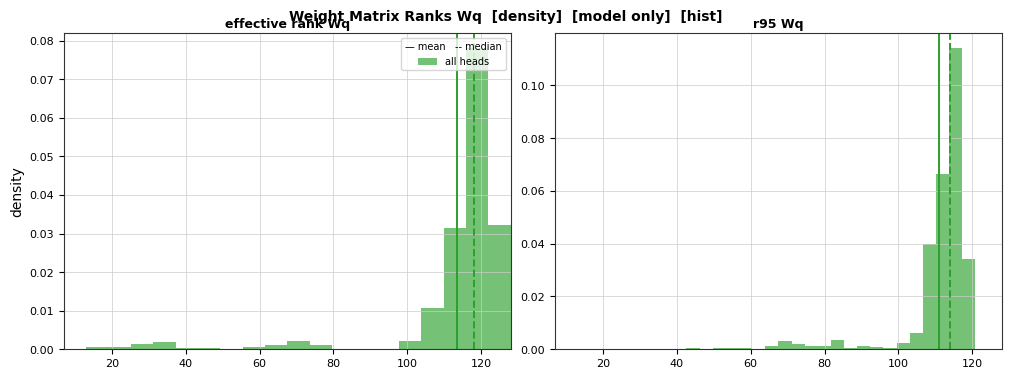


[Weight Matrix Ranks Wk Wv] Per-KV-head slice of W_k/W_v. 8 distinct KV-heads in Mistral-7B (GQA)....


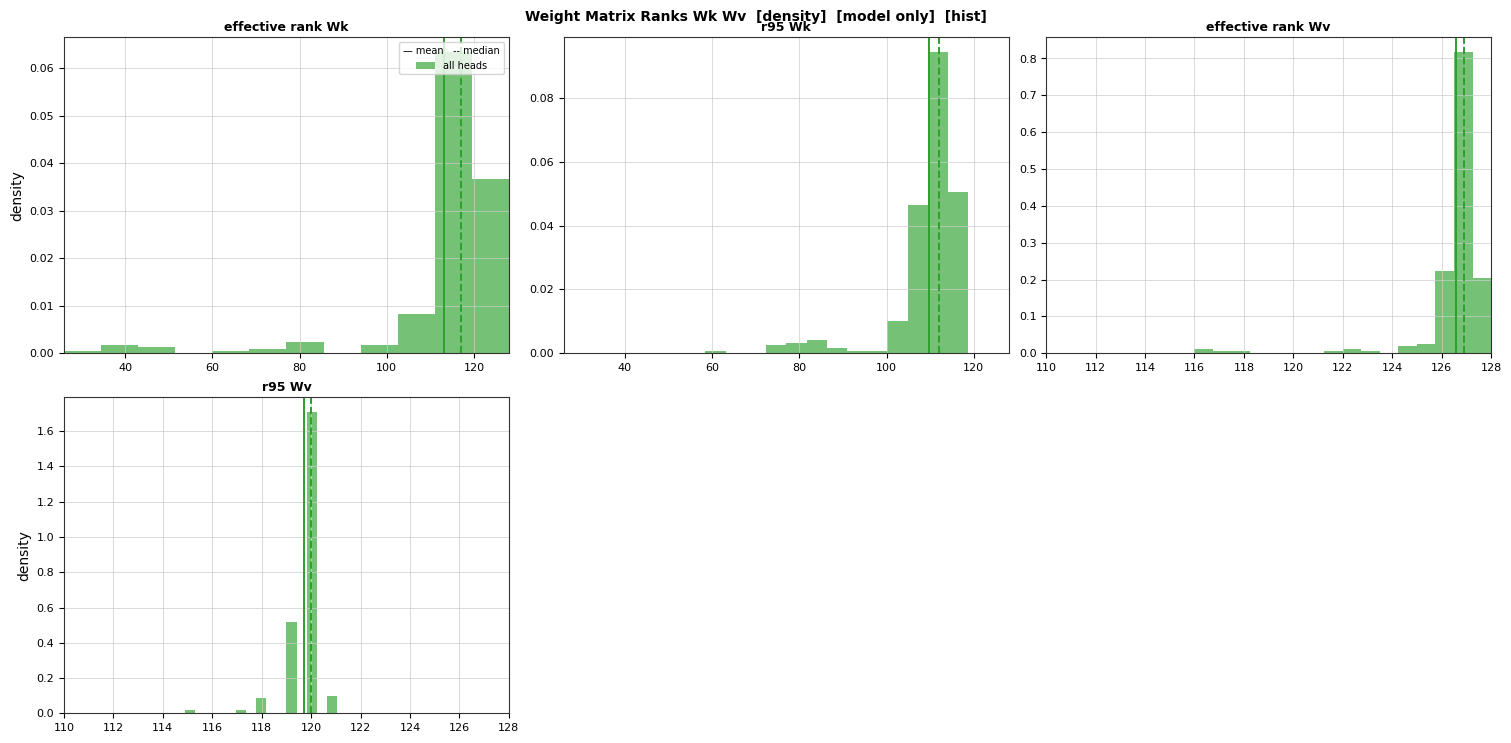


[Gini Spectral Concentration] Gini over left/right singular vectors of W_q/W_k. In [0,1]....


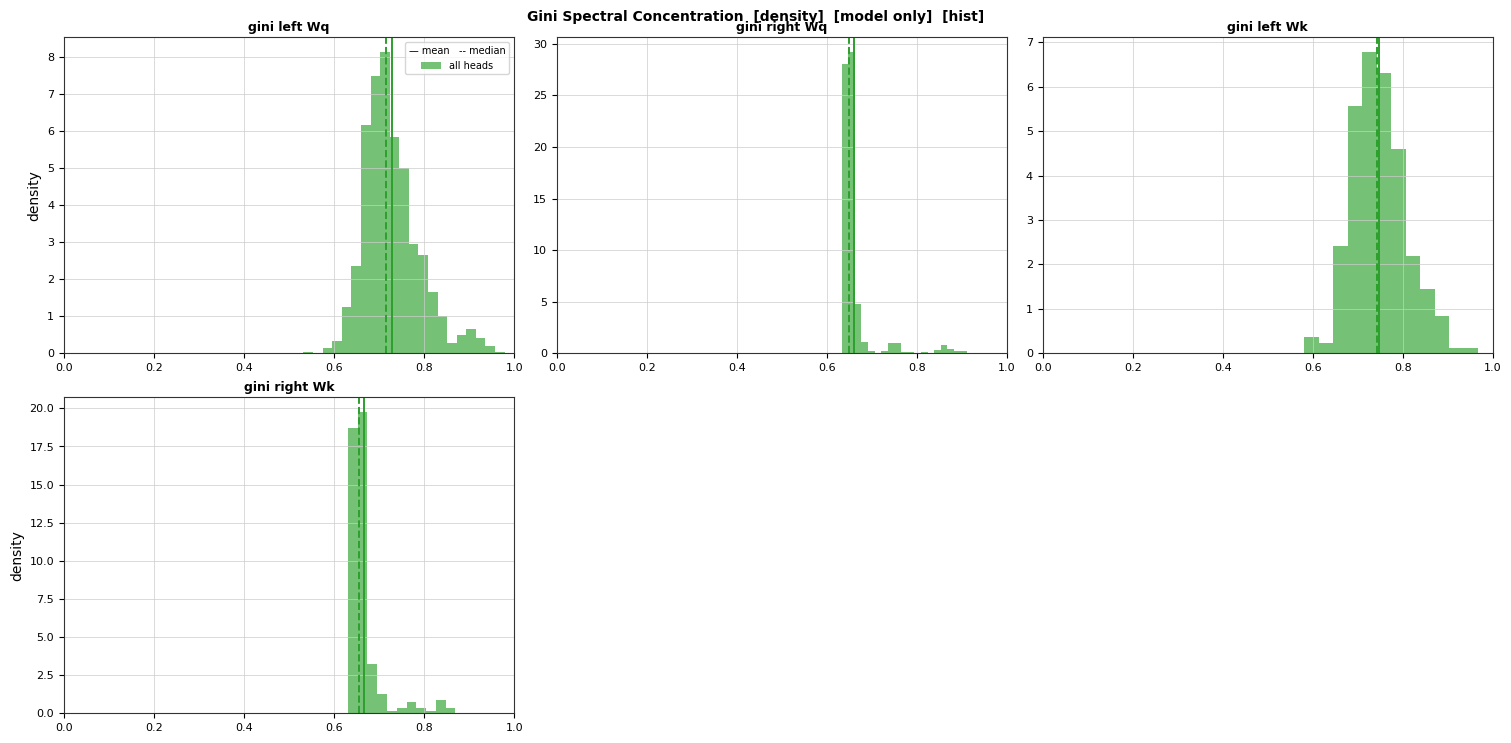


[RMSNorm] L2 norm of RMSNorm gamma. Fixed per layer....


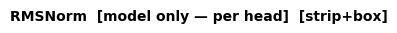


[RoPE Structure] rope_freq_com in [0,63]. rope_pair_max_ratio: dominance of top RoPE pair....


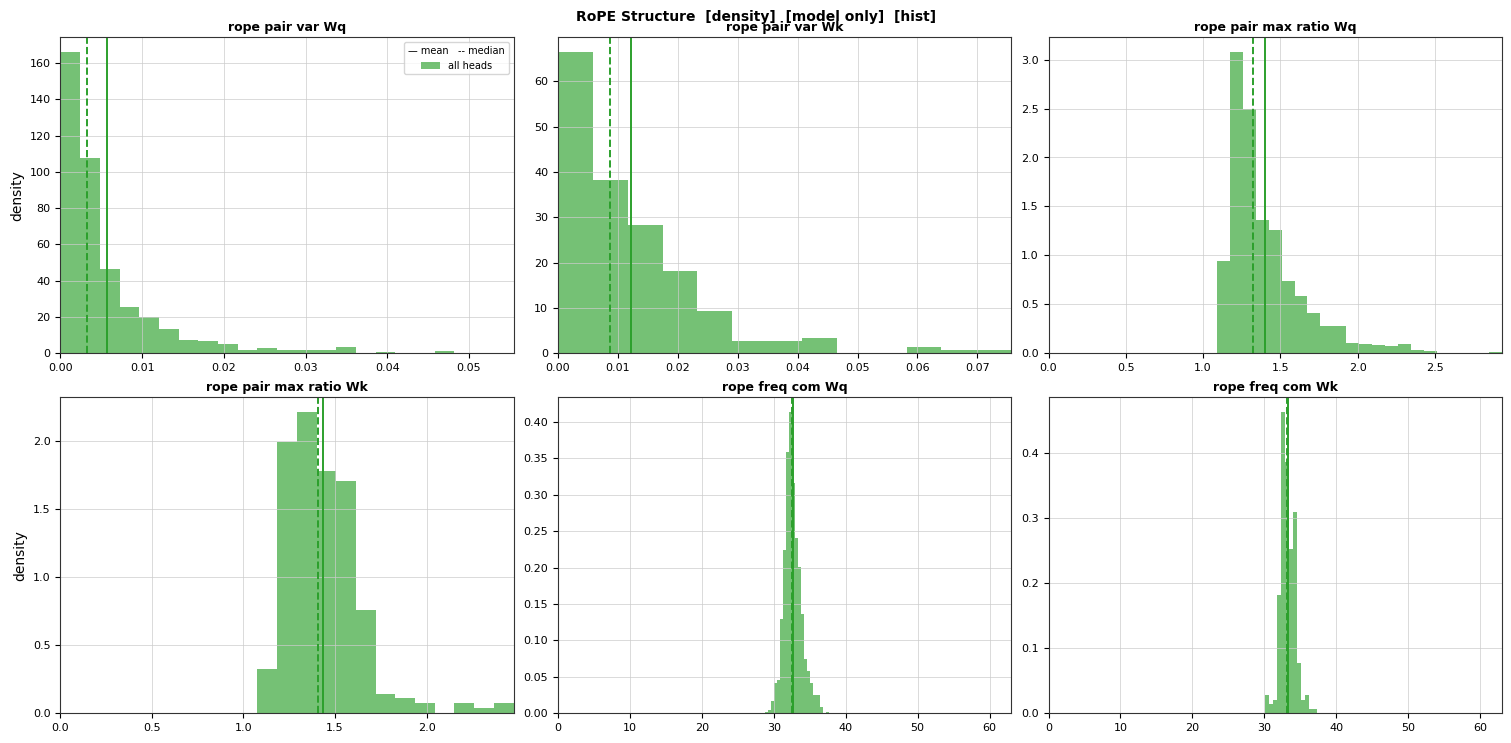


[RoPE-aware QK Alignment] Cosine alignment W_q * R(delta=0) * W_k^T. Pure weight property....


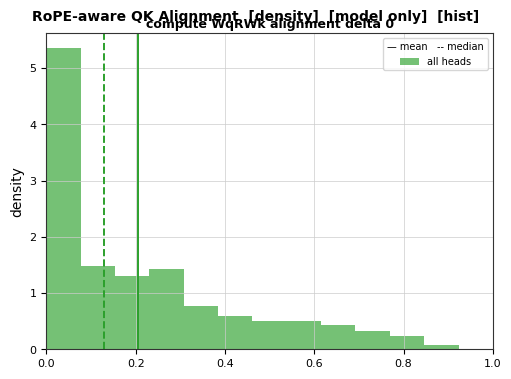


[SVD Alignment H vs W] Cosine sim top singular vector of H vs W_q/W_k. Mixed: W fixed, H input-dep....


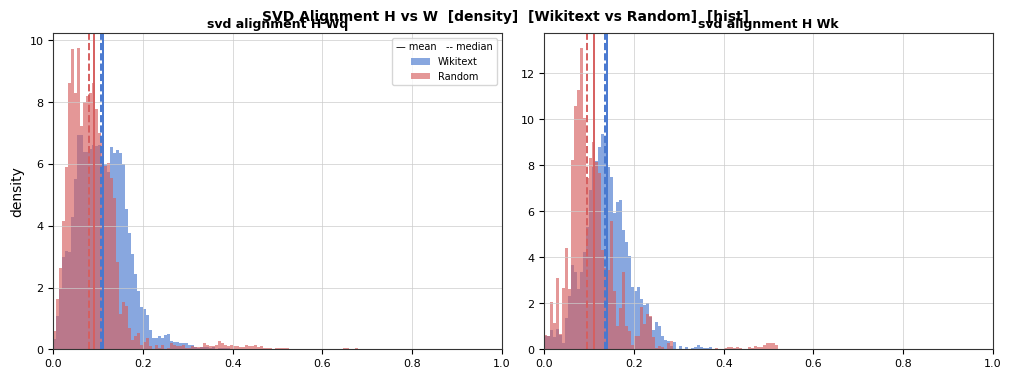

In [102]:
# ── Tre script separati: uno per categoria ────────────────────────────────────

# SCRIPT 1 — Model-Dependent Features
print("=" * 60)
print("SCRIPT 1 — MODEL-DEPENDENT FEATURES")
print("=" * 60)
for subgroup_name, meta in TAXONOMY["model_dependent"].items():
    print(f"\n[{subgroup_name}] {meta['notes'][:80]}...")
    plot_group(subgroup_name, meta, df)



#### Input dependent features

we have two kinds of input:
* Input built as a concatenation of uniformly sampled tokens from the model vocabulary
* Input from the dataset $\texttt{wikitext-103-raw-v1}$

SCRIPT 2 — INPUT-DEPENDENT FEATURES

[Hidden State Rank] H shape (seq_len, 4096). rank_max=min(seq_len,4096)....


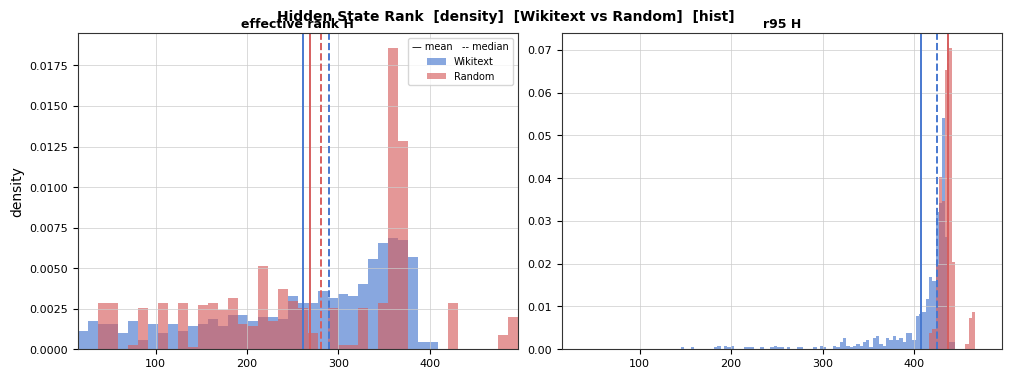


[Projected Q/K Ranks] Q=H*W_q^T, K=H*W_k^T per head. Shape (seq,128)....


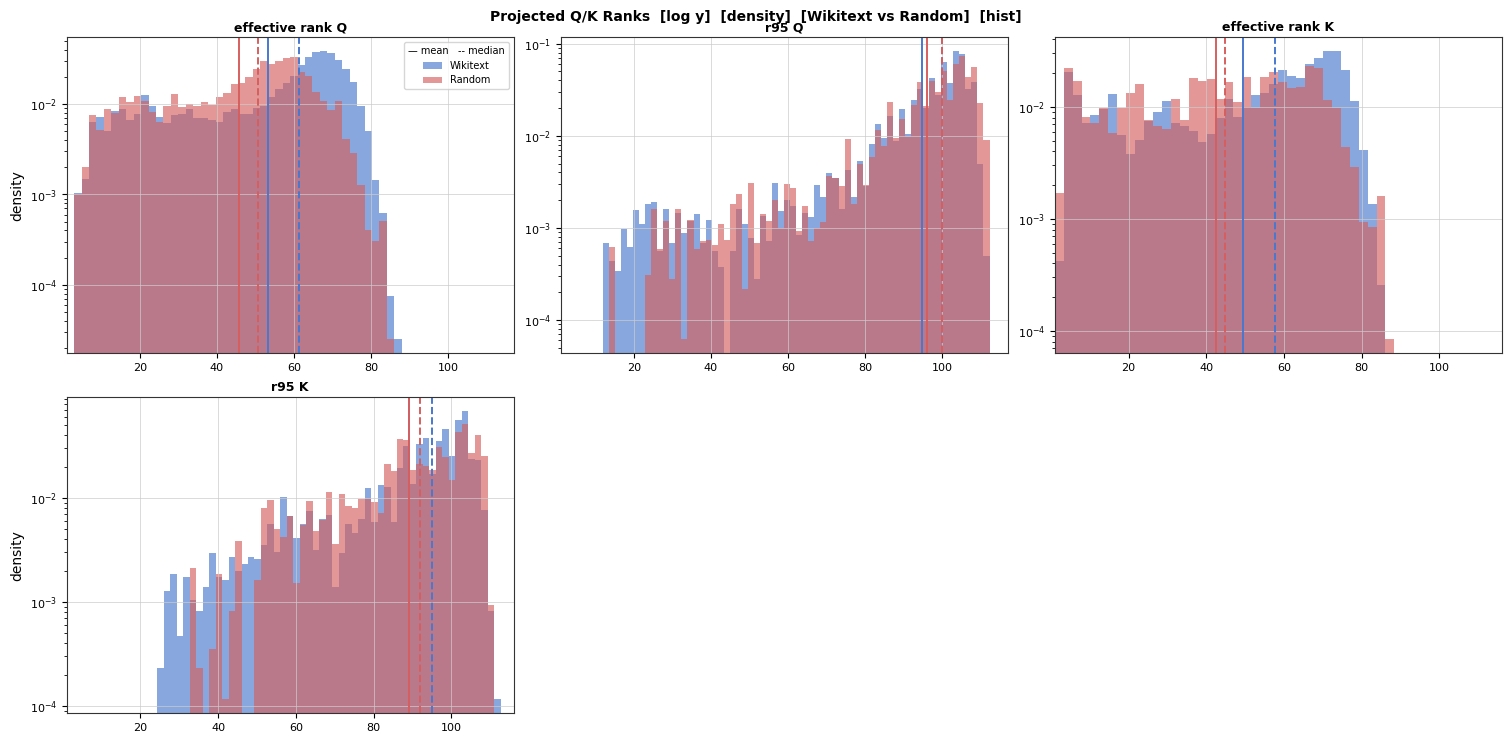


[Temporal Similarity] Mean cosine sim between consecutive token rows of Q/K....


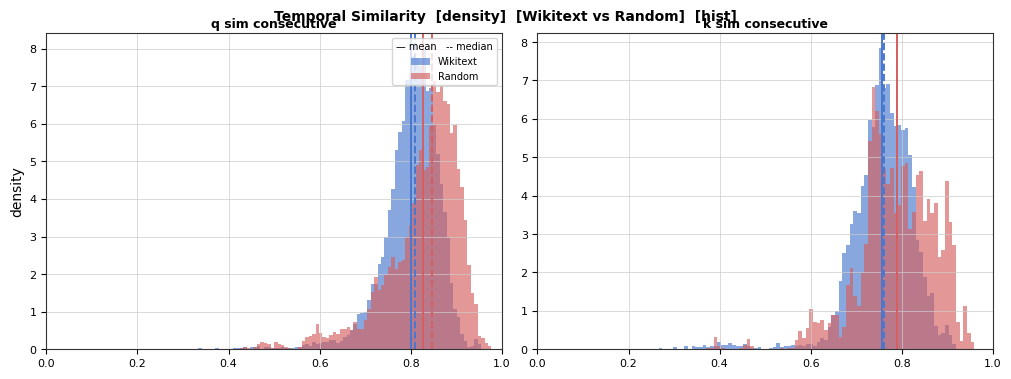

In [105]:
# SCRIPT 2 — Input-Dependent Features
print("=" * 60)
print("SCRIPT 2 — INPUT-DEPENDENT FEATURES")
print("=" * 60)
for subgroup_name, meta in TAXONOMY["input_dependent"].items():
    print(f"\n[{subgroup_name}] {meta['notes'][:80]}...")
    plot_group(subgroup_name, meta, df)


#### Target features

SCRIPT 3 — TARGET FEATURES (ATTENTION MAP)

[Attention Map Diagonal Mass] Attention mass on main diagonal (width 1 or 5) and sub-diagonals....


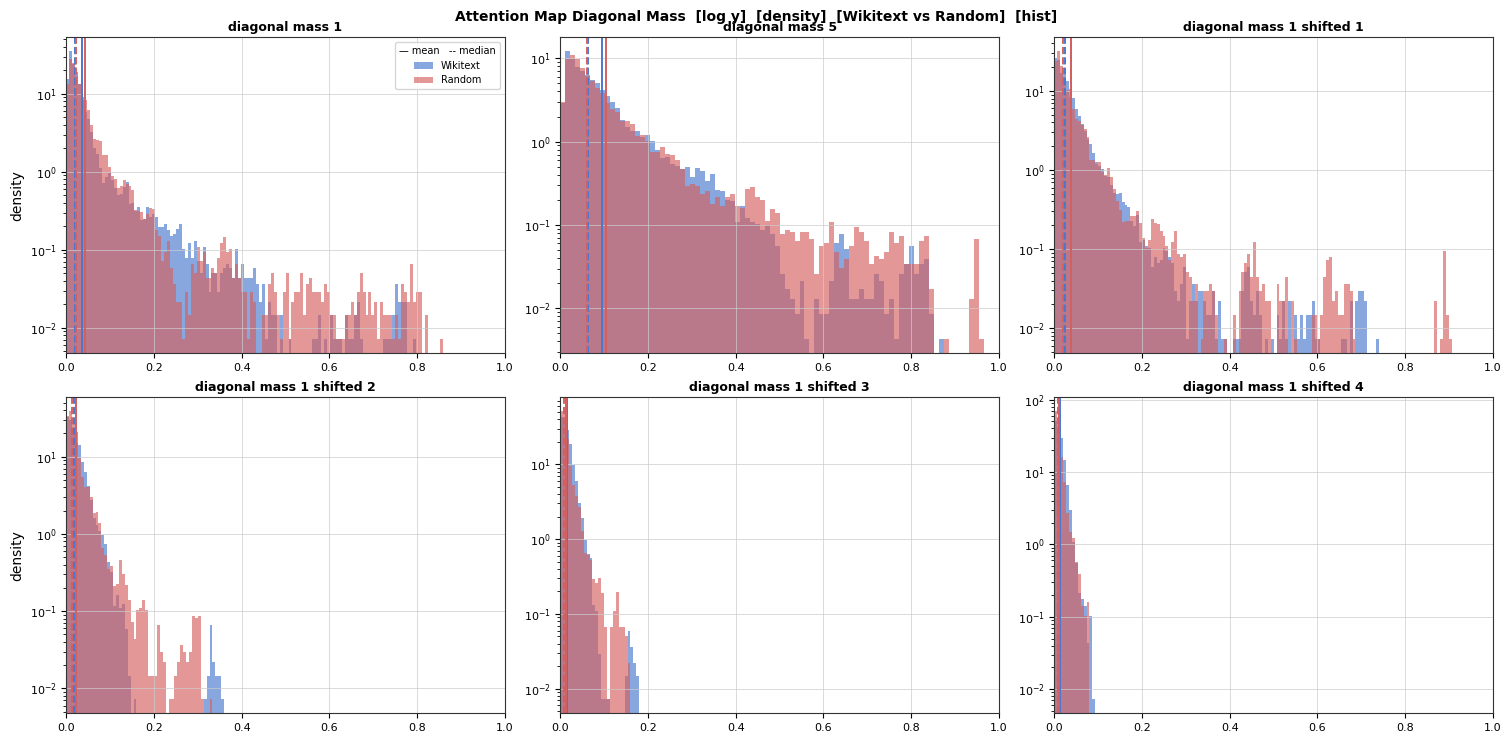


[Attention Map Sink Mass] Attention mass on first 5 tokens (sinks). sink_mass_max = row-wise max....


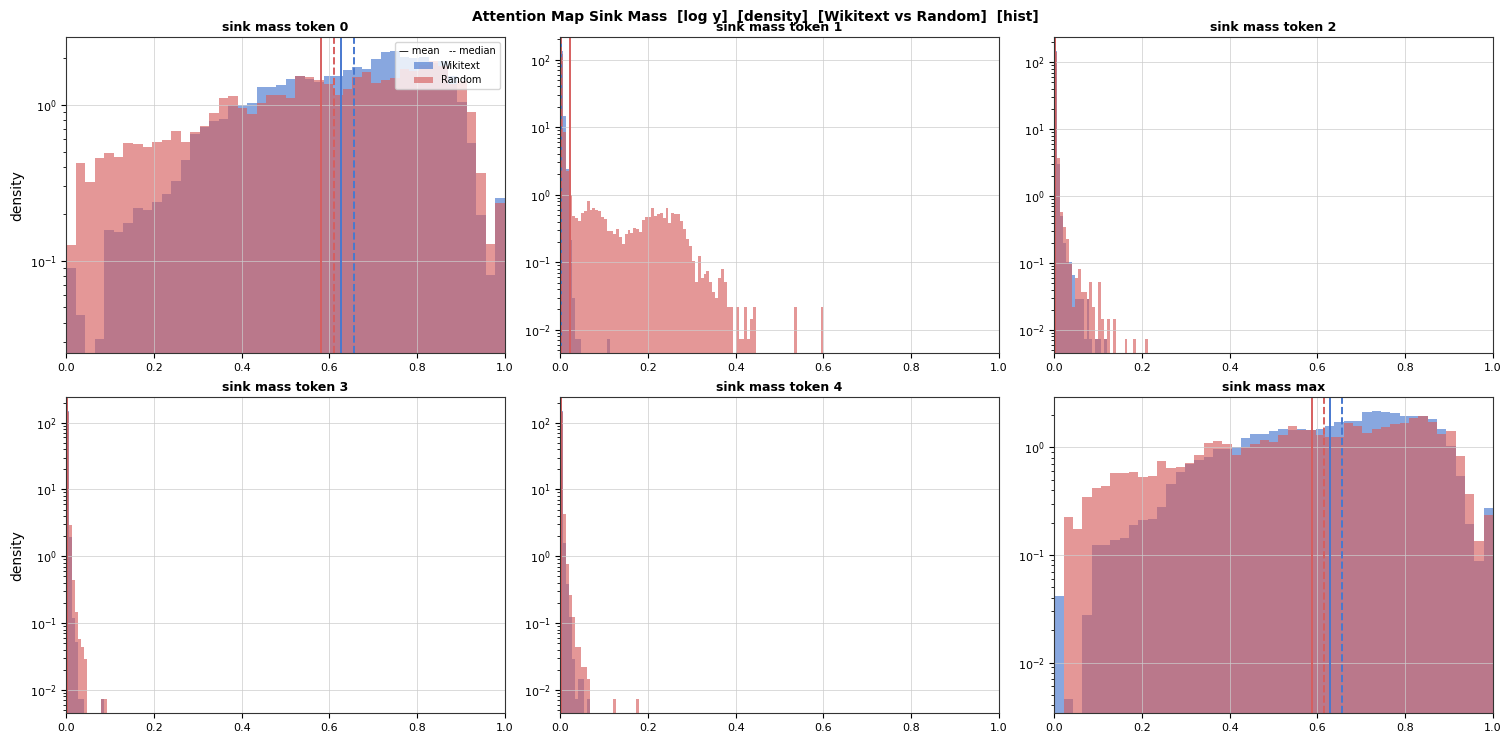


[Attention Map Structure] look_back: mean backward distance norm. attention_gini: row Gini....


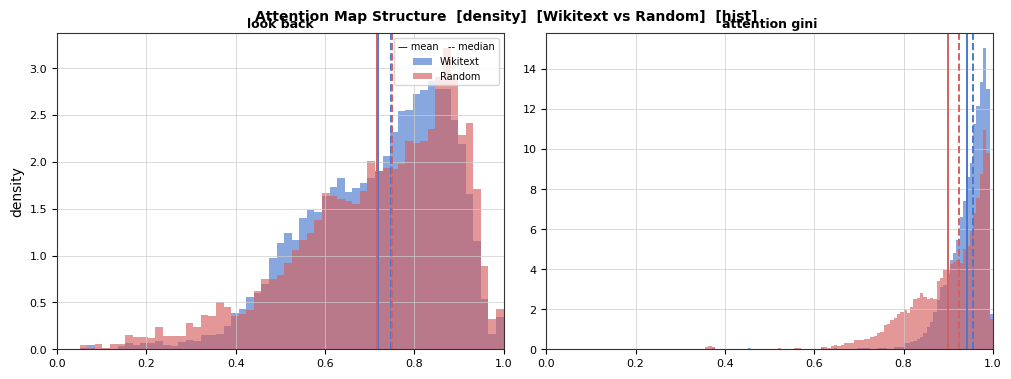


[Attention Matrix Rank] Rank of post-softmax A. Low=sparse, High=diffuse....


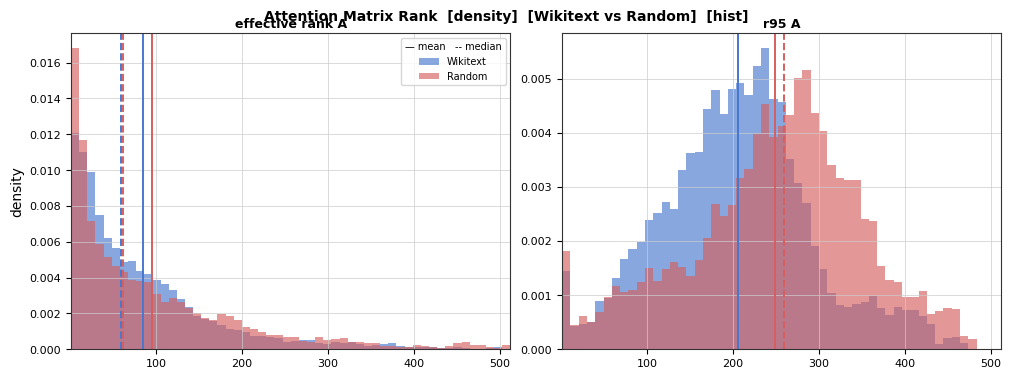

In [106]:

# SCRIPT 3 — Target Features (Attention Map)
print("=" * 60)
print("SCRIPT 3 — TARGET FEATURES (ATTENTION MAP)")
print("=" * 60)
for subgroup_name, meta in TAXONOMY["target"].items():
    print(f"\n[{subgroup_name}] {meta['notes'][:80]}...")
    plot_group(subgroup_name, meta, df)

### Bivariate analysis of features: searching for correlations among fetaures

#### Layer-depth dependent features analysis

### GLM fitting to predict target variables

### LightGBM fitting

#### Cross-prompt generalization

#### Cross-Head generalization

In [5]:
# Focused EDA: correlations (from FEATURE_REGISTRY)
import pandas as pd
import plotly.express as px
import plotly.io as pio
from core.features_library import FEATURE_REGISTRY
pio.renderers.default = "vscode"

sources = sorted(df["prompt_source"].dropna().astype(str).unique().tolist())
print("Prompt sources:", sources)

# META_COLS esclude layer_idx per poterlo usare nella correlazione
META_COLS = {"model_name", "prompt_id", "prompt_source", "head_idx", "run_idx"}

# All numeric features in the dataset
all_numeric_features = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c]) and c not in META_COLS
]

registry_features = list(FEATURE_REGISTRY.keys())
available_registry_features = [f for f in registry_features if f in df.columns]
print(f"Registry features found in df: {len(available_registry_features)}/{len(registry_features)}")
print(f"Total numeric features used for correlation: {len(all_numeric_features)}")

# Canonical feature groups from features_library naming.
model_dependent_features = [
    "effective_rank_Wq", "r95_Wq",
    "effective_rank_Wk", "r95_Wk",
    "effective_rank_Wv", "r95_Wv",
    "rmsnorm_gamma_norm",
    "rope_pair_var_Wq", "rope_pair_var_Wk",
    "rope_pair_max_norm_Wq", "rope_pair_max_norm_Wk",
    "rope_pair_max_ratio_Wq", "rope_pair_max_ratio_Wk",
    "rope_freq_com_Wq", "rope_freq_com_Wk",
    "compute_WqRWk_alignment_delta_0",
    "compute_WqRWk_alignment_delta_1",
    "compute_WqRWk_alignment_delta_2",
    "compute_WqRWk_alignment_delta_3",
    "compute_WqRWk_alignment_delta_4",
]

# LAYER DEPTH (layer_idx) aggiunto come feature di input
input_dependent_features = [
    "layer_idx",
    "effective_rank_H", "r95_H",
    "effective_rank_Q", "r95_Q",
    "effective_rank_K", "r95_K",
    "q_sim_consecutive", "k_sim_consecutive",
    "svd_alignment_H_Wq", "svd_alignment_H_Wk",
]

target_features = [
    "attention_entropy", "attention_gini", "attention_row_var_weighted",
    "diagonal_mass_1", "diagonal_mass_5",
    "diagonal_mass_1_shifted_1", "diagonal_mass_1_shifted_2",
    "diagonal_mass_1_shifted_3", "diagonal_mass_1_shifted_4",
    "sink_mass_token_0", "sink_mass_token_1", "sink_mass_token_2",
    "sink_mass_token_3", "sink_mass_token_4", "sink_mass_max",
    "look_back",
    "effective_rank_A", "r95_A",
]

model_set = set(model_dependent_features)
input_set = set(input_dependent_features)
target_set = set(target_features)

def classify_feature(name):
    if name in model_set:
        return "model"
    if name in input_set:
        return "input"
    if name in target_set:
        return "target"

    n = name.lower()
    if any(k in n for k in ["wq", "wk", "wv", "weight", "rope", "rmsnorm", "gamma"]):
        return "model"
    if any(k in n for k in ["_h", "_q", "_k", "q_sim", "k_sim", "svd_alignment_h", "layer_idx"]):
        return "input"
    return "target"

def ordered_group(features, canonical_order):
    present = [f for f in canonical_order if f in features]
    rest = sorted([f for f in features if f not in set(canonical_order)], key=str.lower)
    return present + rest

model_group = [f for f in all_numeric_features if classify_feature(f) == "model"]
input_group = [f for f in all_numeric_features if classify_feature(f) == "input"]
target_group = [f for f in all_numeric_features if classify_feature(f) == "target"]

model_group = ordered_group(model_group, model_dependent_features)
input_group = ordered_group(input_group, input_dependent_features)
target_group = ordered_group(target_group, target_features)

sorted_features = model_group + input_group + target_group

print("Feature ordering for correlation:")
print("  model-dependent:", len(model_group))
print("  input-dependent:", len(input_group))
print("  target:", len(target_group))

# Boundaries used to draw dividers between the three blocks.
b1 = len(model_group)
b2 = len(model_group) + len(input_group)
boundaries = [b for b in [b1, b2] if 0 < b < len(sorted_features)]

def add_group_dividers(fig, n_features, boundaries):
    for b in boundaries:
        pos = b - 0.5
        fig.add_shape(
            type="line",
            x0=pos, x1=pos, y0=-0.5, y1=n_features - 0.5,
            line=dict(color="black", width=2),
        )
        fig.add_shape(
            type="line",
            x0=-0.5, x1=n_features - 0.5, y0=pos, y1=pos,
            line=dict(color="black", width=2),
        )

def find_source(keyword, fallback_index=None):
    matches = [s for s in sources if keyword in s.lower()]
    if matches:
        return matches[0]
    if fallback_index is not None and fallback_index < len(sources):
        return sources[fallback_index]
    return None

random_source = find_source("random", fallback_index=0)
wikitext_source = find_source("wiki", fallback_index=1 if len(sources) > 1 else 0)

for label, src in [("Random dataset", random_source), ("WikiText dataset", wikitext_source)]:
    if src is None:
        print(f"[Skip] {label}: source not found in prompt_source column.")
        continue

    sub = df[df["prompt_source"] == src]
    if sub.empty:
        print(f"[Skip] {label}: no rows for source={src}.")
        continue

    corr = sub[sorted_features].corr()
    fig = px.imshow(
        corr,
        color_continuous_scale="RdBu_r",
        zmin=-1,
        zmax=1,
        title=f"<b>Correlation Matrix</b> — {label} ({src})",
        labels={"x": "Feature", "y": "Feature", "color": "Correlation"},
    )
    fig.update_xaxes(tickangle=-45)
    add_group_dividers(fig, n_features=len(sorted_features), boundaries=boundaries)
    fig.update_layout(width=1000, height=900)
    fig.show()

Prompt sources: ['wikitext_wikitext-103-raw-v1_train']
Registry features found in df: 48/48
Total numeric features used for correlation: 50
Feature ordering for correlation:
  model-dependent: 20
  input-dependent: 11
  target: 19


In [6]:
# Focused EDA: correlations (from FEATURE_REGISTRY) divided by layer thirds
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
from core.features_library import FEATURE_REGISTRY
pio.renderers.default = "vscode"

sources = sorted(df["prompt_source"].dropna().astype(str).unique().tolist())
print("Prompt sources:", sources)

META_COLS = {"model_name", "prompt_id", "prompt_source", "layer_idx", "head_idx", "run_idx"}

# All numeric features in the dataset (not only registry columns).
all_numeric_features = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c]) and c not in META_COLS
]

registry_features = list(FEATURE_REGISTRY.keys())
available_registry_features = [f for f in registry_features if f in df.columns]
print(f"Registry features found in df: {len(available_registry_features)}/{len(registry_features)}")
print(f"Total numeric features used for correlation: {len(all_numeric_features)}")

# Canonical feature groups from features_library naming.
model_dependent_features = [
    "effective_rank_Wq", "r95_Wq",
    "effective_rank_Wk", "r95_Wk",
    "effective_rank_Wv", "r95_Wv",
    #"rmsnorm_gamma_norm",
    "rope_pair_var_Wq", "rope_pair_var_Wk",
    "rope_pair_max_norm_Wq", "rope_pair_max_norm_Wk",
    "rope_pair_max_ratio_Wq", "rope_pair_max_ratio_Wk",
    "rope_freq_com_Wq", "rope_freq_com_Wk",
    "compute_WqRWk_alignment_delta_0",
    "compute_WqRWk_alignment_delta_1",
    "compute_WqRWk_alignment_delta_2",
    "compute_WqRWk_alignment_delta_3",
    "compute_WqRWk_alignment_delta_4",
]

input_dependent_features = [
    "effective_rank_H", "r95_H",
    "effective_rank_Q", "r95_Q",
    "effective_rank_K", "r95_K",
    "q_sim_consecutive", "k_sim_consecutive",
    "svd_alignment_H_Wq", "svd_alignment_H_Wk",
]

target_features = [
    "attention_entropy", "attention_gini", "attention_row_var_weighted",
    "diagonal_mass_1", "diagonal_mass_5",
    "diagonal_mass_1_shifted_1", "diagonal_mass_1_shifted_2",
    "diagonal_mass_1_shifted_3", "diagonal_mass_1_shifted_4",
    "sink_mass_token_0", "sink_mass_token_1", "sink_mass_token_2",
    "sink_mass_token_3", "sink_mass_token_4", "sink_mass_max",
    "look_back",
    "effective_rank_A", "r95_A",
]

model_set = set(model_dependent_features)
input_set = set(input_dependent_features)
target_set = set(target_features)

def classify_feature(name):
    if name in model_set:
        return "model"
    if name in input_set:
        return "input"
    if name in target_set:
        return "target"

    n = name.lower()
    if any(k in n for k in ["wq", "wk", "wv", "weight", "rope", "rmsnorm", "gamma"]):
        return "model"
    if any(k in n for k in ["_h", "_q", "_k", "q_sim", "k_sim", "svd_alignment_h"]):
        return "input"
    return "target"

def ordered_group(features, canonical_order):
    present = [f for f in canonical_order if f in features]
    rest = sorted([f for f in features if f not in set(canonical_order)], key=str.lower)
    return present + rest

model_group = [f for f in all_numeric_features if classify_feature(f) == "model"]
input_group = [f for f in all_numeric_features if classify_feature(f) == "input"]
target_group = [f for f in all_numeric_features if classify_feature(f) == "target"]

model_group = ordered_group(model_group, model_dependent_features)
input_group = ordered_group(input_group, input_dependent_features)
target_group = ordered_group(target_group, target_features)

sorted_features = model_group + input_group + target_group

print("Feature ordering for correlation:")
print("  model-dependent:", len(model_group))
print("  input-dependent:", len(input_group))
print("  target:", len(target_group))

# Boundaries used to draw dividers between the three blocks.
b1 = len(model_group)
b2 = len(model_group) + len(input_group)
boundaries = [b for b in [b1, b2] if 0 < b < len(sorted_features)]

def add_group_dividers(fig, n_features, boundaries):
    for b in boundaries:
        pos = b - 0.5
        fig.add_shape(
            type="line",
            x0=pos, x1=pos, y0=-0.5, y1=n_features - 0.5,
            line=dict(color="black", width=2),
        )
        fig.add_shape(
            type="line",
            x0=-0.5, x1=n_features - 0.5, y0=pos, y1=pos,
            line=dict(color="black", width=2),
        )

def find_source(keyword, fallback_index=None):
    matches = [s for s in sources if keyword in s.lower()]
    if matches:
        return matches[0]
    if fallback_index is not None and fallback_index < len(sources):
        return sources[fallback_index]
    return None

random_source = find_source("random", fallback_index=0)
wikitext_source = find_source("wiki", fallback_index=1 if len(sources) > 1 else 0)

# --- SPLITTING LAYERS INTO THIRDS ---
unique_layers = sorted(df["layer_idx"].dropna().unique())
# Split the layers array into 3 roughly equal parts
layer_thirds = np.array_split(unique_layers, 3)
third_names = ["Early Layers", "Middle Layers", "Late Layers"]

for label, src in [("Random dataset", random_source), ("WikiText dataset", wikitext_source)]:
    if src is None:
        print(f"[Skip] {label}: source not found in prompt_source column.")
        continue

    # Get data for the specific prompt source
    sub_src = df[df["prompt_source"] == src]
    if sub_src.empty:
        print(f"[Skip] {label}: no rows for source={src}.")
        continue

    # Plot a correlation matrix for each third of the network
    for i, layer_group in enumerate(layer_thirds):
        # Filter dataframe by the current layer group
        sub = sub_src[sub_src["layer_idx"].isin(layer_group)]
        
        if sub.empty:
            continue
            
        group_label = f"{third_names[i]} ({layer_group[0]} to {layer_group[-1]})"
        corr = sub[sorted_features].corr()
        
        fig = px.imshow(
            corr,
            color_continuous_scale="RdBu_r",
            zmin=-1,
            zmax=1,
            title=f"<b>Correlation Matrix</b> — {label} <br><sup>{group_label}</sup>",
            labels={"x": "Feature", "y": "Feature", "color": "Correlation"},
        )
        fig.update_xaxes(tickangle=-45)
        add_group_dividers(fig, n_features=len(sorted_features), boundaries=boundaries)
        fig.update_layout(width=1000, height=900)
        fig.show()

Prompt sources: ['wikitext_wikitext-103-raw-v1_train']
Registry features found in df: 48/48
Total numeric features used for correlation: 49
Feature ordering for correlation:
  model-dependent: 20
  input-dependent: 10
  target: 19


# Rank W_q W_k W_v correlations

Generating Q vs K effective ranks plot...
Generating Q vs K R95 plot...
Generating V vs K effective ranks plot...
Generating V vs K R95 plot...
Generating Q vs V effective ranks plot...
Generating Q vs V R95 plot...
Generating effective ranks distribution plot...
Generating R95 distribution plot...


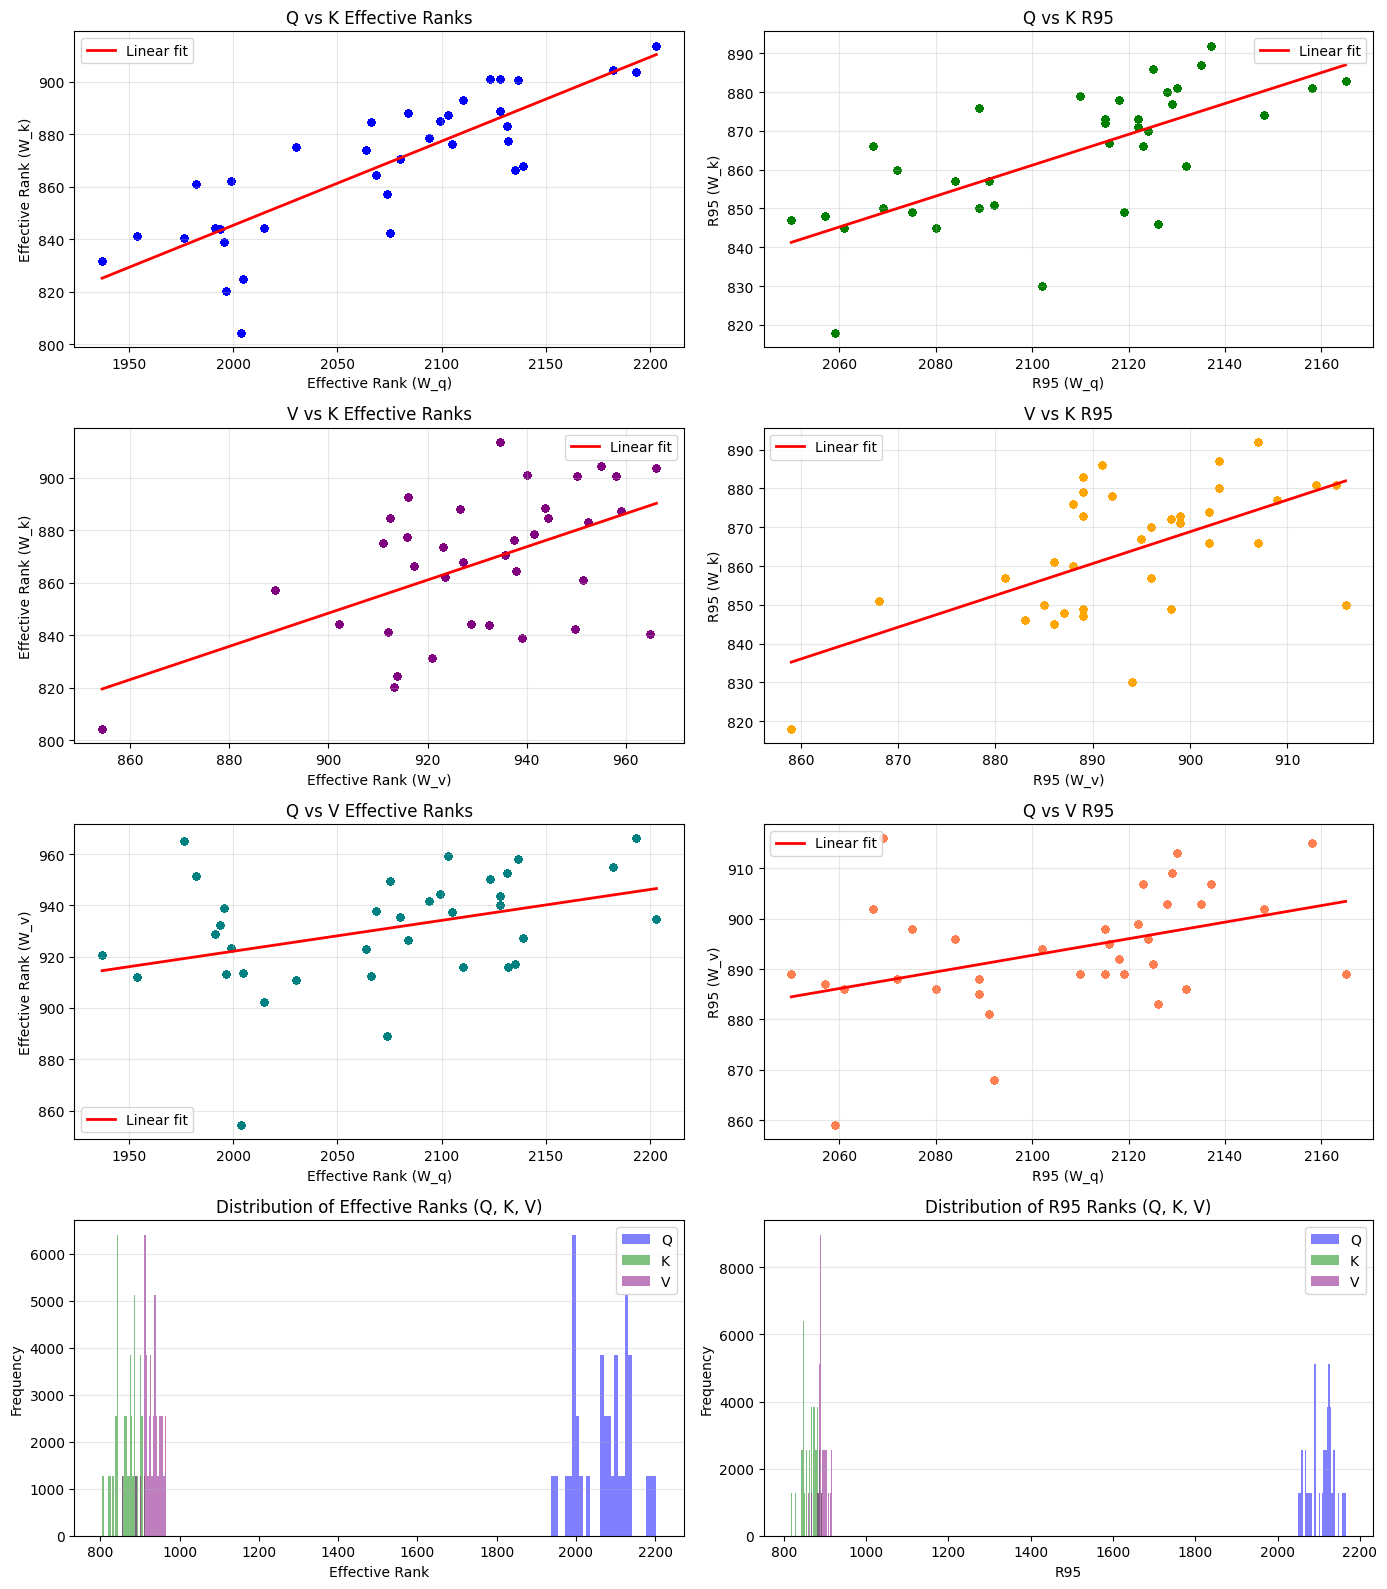

All rank analysis plots generated successfully!


In [50]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# ==================== RANK ANALYSIS PLOTS ====================

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

# 1. Q vs K Effective Ranks with interpolation
print("Generating Q vs K effective ranks plot...")
q_erank = df['effective_rank_Wq'].values
k_erank = df['effective_rank_Wk'].values

mask = ~(np.isnan(q_erank) | np.isnan(k_erank))
q_erank_clean = q_erank[mask]
k_erank_clean = k_erank[mask]

z = np.polyfit(q_erank_clean, k_erank_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(q_erank_clean.min(), q_erank_clean.max(), 100)
y_trend = p(x_trend)

axes[0, 0].scatter(q_erank_clean, k_erank_clean, alpha=0.5, s=20, color='blue')
axes[0, 0].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[0, 0].set_xlabel('Effective Rank (W_q)')
axes[0, 0].set_ylabel('Effective Rank (W_k)')
axes[0, 0].set_title('Q vs K Effective Ranks')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Q vs K R95 with interpolation
print("Generating Q vs K R95 plot...")
q_r95 = df['r95_Wq'].values
k_r95 = df['r95_Wk'].values

mask = ~(np.isnan(q_r95) | np.isnan(k_r95))
q_r95_clean = q_r95[mask]
k_r95_clean = k_r95[mask]

z = np.polyfit(q_r95_clean, k_r95_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(q_r95_clean.min(), q_r95_clean.max(), 100)
y_trend = p(x_trend)

axes[0, 1].scatter(q_r95_clean, k_r95_clean, alpha=0.5, s=20, color='green')
axes[0, 1].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[0, 1].set_xlabel('R95 (W_q)')
axes[0, 1].set_ylabel('R95 (W_k)')
axes[0, 1].set_title('Q vs K R95')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. V vs K Effective Ranks with interpolation
print("Generating V vs K effective ranks plot...")
v_erank = df['effective_rank_Wv'].values
k_erank = df['effective_rank_Wk'].values

mask = ~(np.isnan(v_erank) | np.isnan(k_erank))
v_erank_clean = v_erank[mask]
k_erank_clean = k_erank[mask]

z = np.polyfit(v_erank_clean, k_erank_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(v_erank_clean.min(), v_erank_clean.max(), 100)
y_trend = p(x_trend)

axes[1, 0].scatter(v_erank_clean, k_erank_clean, alpha=0.5, s=20, color='purple')
axes[1, 0].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[1, 0].set_xlabel('Effective Rank (W_v)')
axes[1, 0].set_ylabel('Effective Rank (W_k)')
axes[1, 0].set_title('V vs K Effective Ranks')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. V vs K R95 with interpolation
print("Generating V vs K R95 plot...")
v_r95 = df['r95_Wv'].values
k_r95 = df['r95_Wk'].values

mask = ~(np.isnan(v_r95) | np.isnan(k_r95))
v_r95_clean = v_r95[mask]
k_r95_clean = k_r95[mask]

z = np.polyfit(v_r95_clean, k_r95_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(v_r95_clean.min(), v_r95_clean.max(), 100)
y_trend = p(x_trend)

axes[1, 1].scatter(v_r95_clean, k_r95_clean, alpha=0.5, s=20, color='orange')
axes[1, 1].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[1, 1].set_xlabel('R95 (W_v)')
axes[1, 1].set_ylabel('R95 (W_k)')
axes[1, 1].set_title('V vs K R95')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Q vs V Effective Ranks with interpolation
print("Generating Q vs V effective ranks plot...")
q_erank = df['effective_rank_Wq'].values
v_erank = df['effective_rank_Wv'].values

mask = ~(np.isnan(q_erank) | np.isnan(v_erank))
q_erank_clean = q_erank[mask]
v_erank_clean = v_erank[mask]

z = np.polyfit(q_erank_clean, v_erank_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(q_erank_clean.min(), q_erank_clean.max(), 100)
y_trend = p(x_trend)

axes[2, 0].scatter(q_erank_clean, v_erank_clean, alpha=0.5, s=20, color='teal')
axes[2, 0].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[2, 0].set_xlabel('Effective Rank (W_q)')
axes[2, 0].set_ylabel('Effective Rank (W_v)')
axes[2, 0].set_title('Q vs V Effective Ranks')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Q vs V R95 with interpolation
print("Generating Q vs V R95 plot...")
q_r95 = df['r95_Wq'].values
v_r95 = df['r95_Wv'].values

mask = ~(np.isnan(q_r95) | np.isnan(v_r95))
q_r95_clean = q_r95[mask]
v_r95_clean = v_r95[mask]

z = np.polyfit(q_r95_clean, v_r95_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(q_r95_clean.min(), q_r95_clean.max(), 100)
y_trend = p(x_trend)

axes[2, 1].scatter(q_r95_clean, v_r95_clean, alpha=0.5, s=20, color='coral')
axes[2, 1].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[2, 1].set_xlabel('R95 (W_q)')
axes[2, 1].set_ylabel('R95 (W_v)')
axes[2, 1].set_title('Q vs V R95')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

# 7. Distribution of Effective Ranks for Q, K, V
print("Generating effective ranks distribution plot...")
q_erank_data = df['effective_rank_Wq'].dropna()
k_erank_data = df['effective_rank_Wk'].dropna()
v_erank_data = df['effective_rank_Wv'].dropna()

axes[3, 0].hist(q_erank_data, alpha=0.5, bins=30, label='Q', color='blue')
axes[3, 0].hist(k_erank_data, alpha=0.5, bins=30, label='K', color='green')
axes[3, 0].hist(v_erank_data, alpha=0.5, bins=30, label='V', color='purple')
axes[3, 0].set_xlabel('Effective Rank')
axes[3, 0].set_ylabel('Frequency')
axes[3, 0].set_title('Distribution of Effective Ranks (Q, K, V)')
axes[3, 0].legend()
axes[3, 0].grid(True, alpha=0.3, axis='y')

# 8. Distribution of R95 for Q, K, V
print("Generating R95 distribution plot...")
q_r95_data = df['r95_Wq'].dropna()
k_r95_data = df['r95_Wk'].dropna()
v_r95_data = df['r95_Wv'].dropna()

axes[3, 1].hist(q_r95_data, alpha=0.5, bins=30, label='Q', color='blue')
axes[3, 1].hist(k_r95_data, alpha=0.5, bins=30, label='K', color='green')
axes[3, 1].hist(v_r95_data, alpha=0.5, bins=30, label='V', color='purple')
axes[3, 1].set_xlabel('R95')
axes[3, 1].set_ylabel('Frequency')
axes[3, 1].set_title('Distribution of R95 Ranks (Q, K, V)')
axes[3, 1].legend()
axes[3, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("All rank analysis plots generated successfully!")

In [23]:
df2 = pd.read_csv('mistral_svd_per_head.csv')

df2.head()

,layer,proj,head,erank,stable_rank,r95,s_max,s_min,nuclear_norm,frobenius_norm
0,0,Q,0,31.393368,2.668695,9,1.711842,0.001223,10.890224,2.796489
1,0,Q,1,34.844082,2.185940,10,1.565804,0.000845,9.181295,2.315029
2,0,Q,2,35.192970,3.040336,12,1.844155,0.001318,13.903393,3.215572
3,0,Q,3,28.376802,2.688489,10,2.295821,0.001162,14.682674,3.764369
4,0,Q,4,28.151314,1.860957,7,1.296839,0.000574,6.161576,1.769108


Paired DataFrame: (1024, 9)  → attesi 1024 = 1024 righe


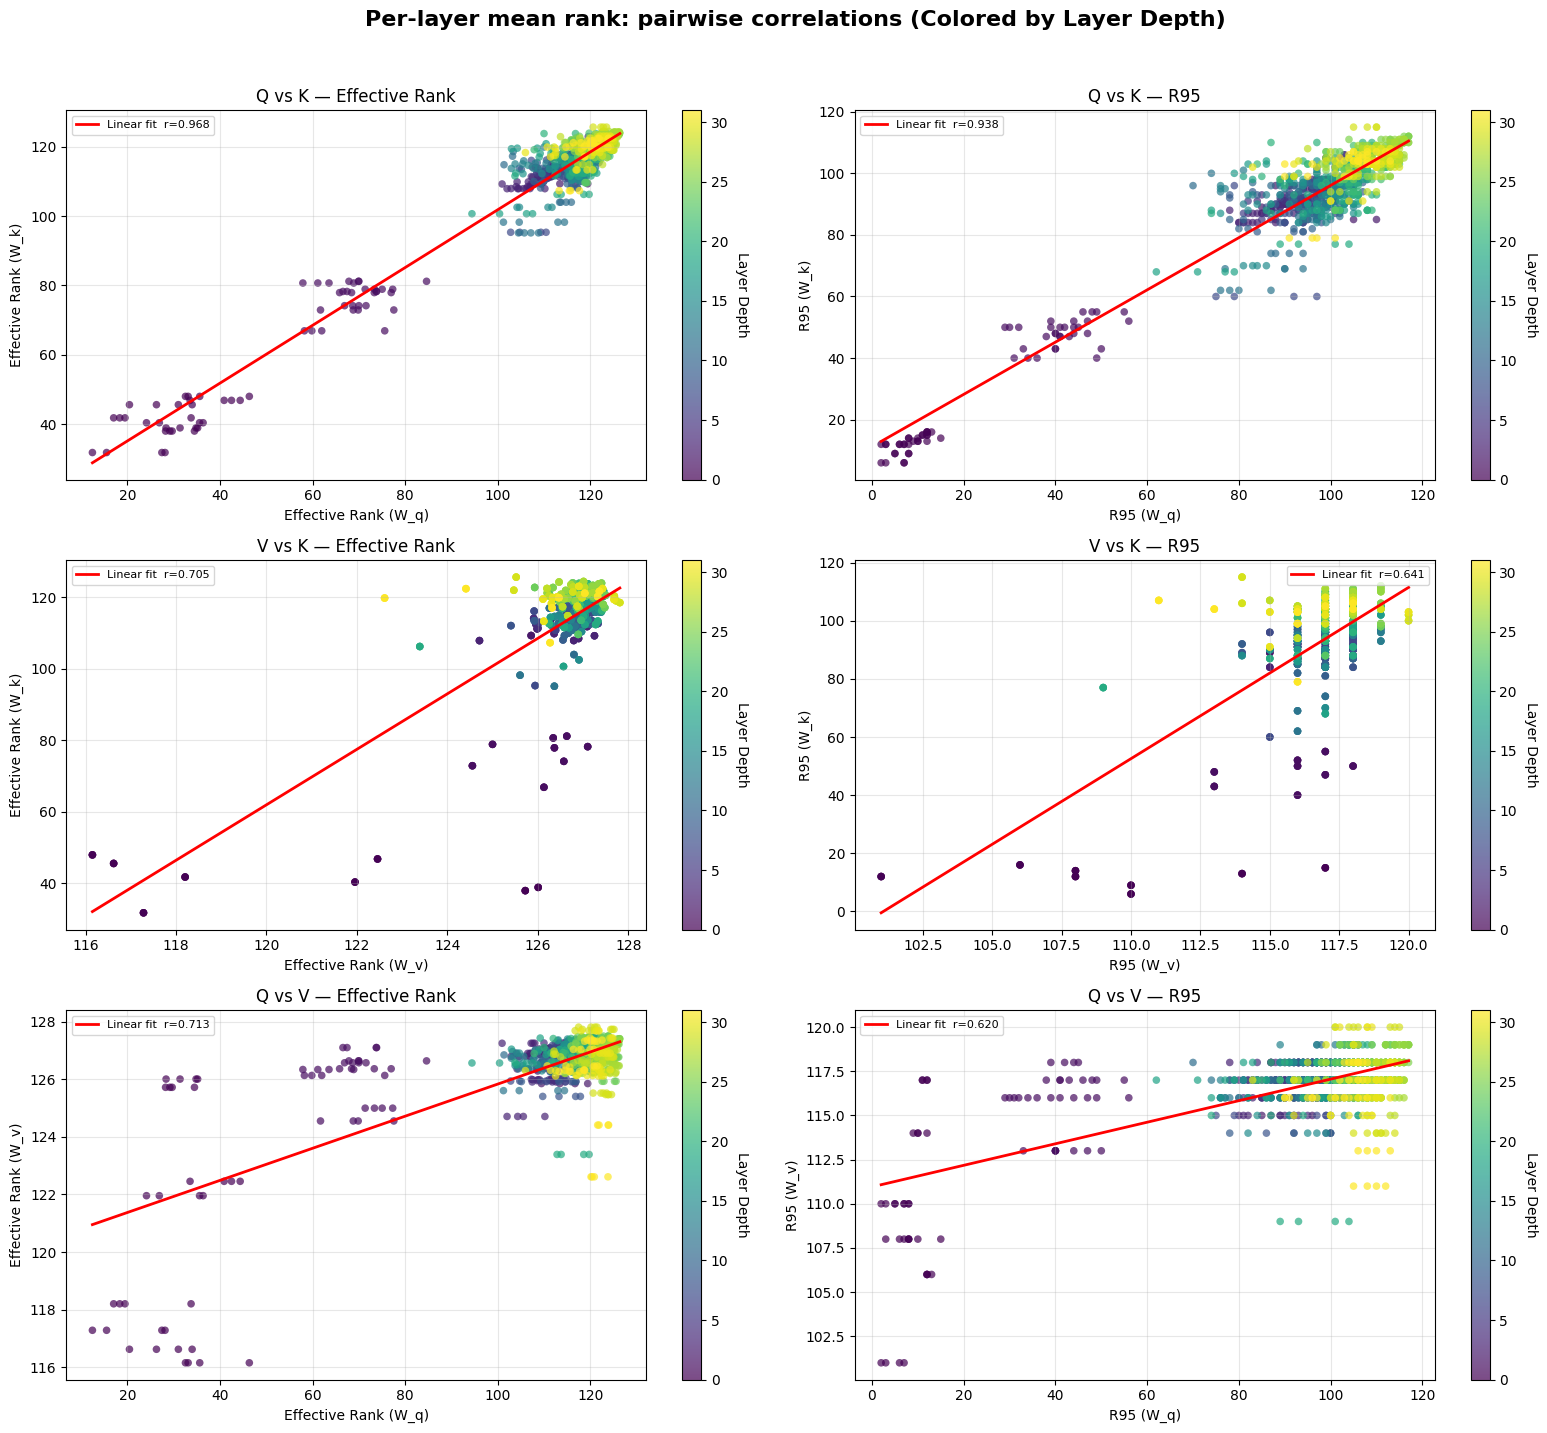

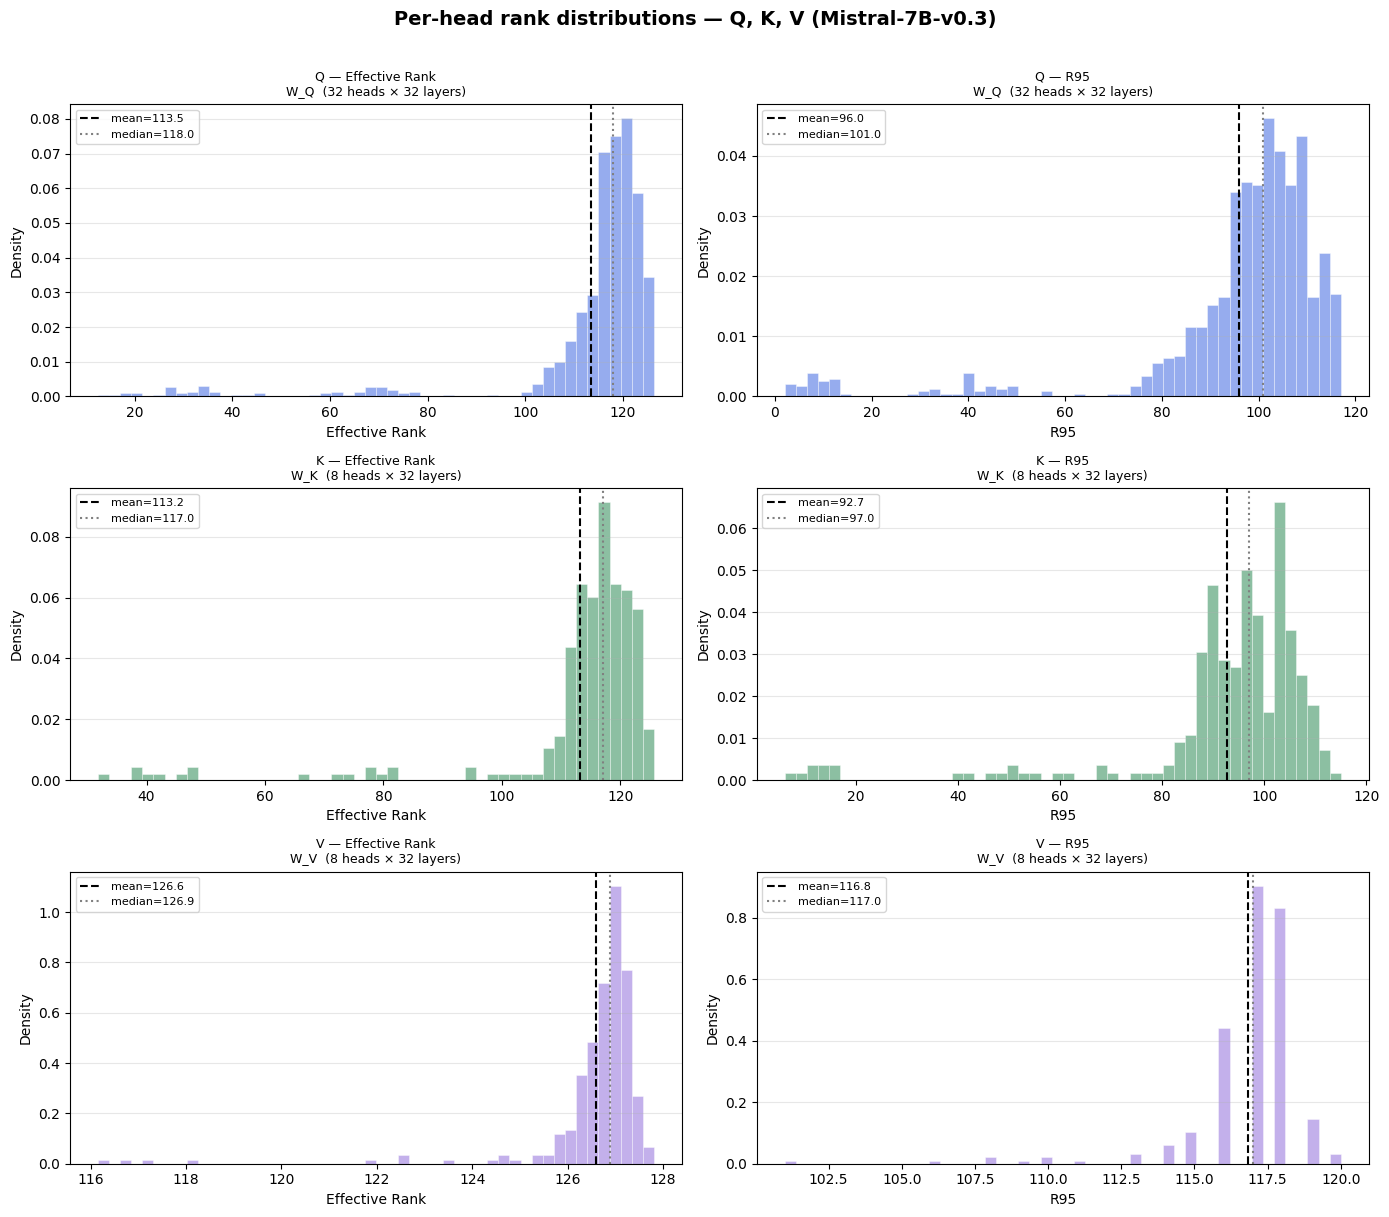

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# ── Pairing per-head con GQA (32 Q-heads, 8 KV-heads, ratio 4:1) ─────────────
# Per ogni layer: K-head 0 → Q-heads 0-3, K-head 1 → Q-heads 4-7, ecc.

records_paired = []

for layer in df2["layer_idx"].unique():
    q_data = df2[(df2["layer_idx"] == layer) & (df2["proj"] == "Q")].sort_values("head_idx").reset_index(drop=True)
    k_data = df2[(df2["layer_idx"] == layer) & (df2["proj"] == "K")].sort_values("head_idx").reset_index(drop=True)
    v_data = df2[(df2["layer_idx"] == layer) & (df2["proj"] == "V")].sort_values("head_idx").reset_index(drop=True)

    n_q    = len(q_data)
    n_kv   = len(k_data)
    ratio  = n_q // n_kv  # = 4 per Mistral GQA

    for q_idx in range(n_q):
        kv_idx = q_idx // ratio  # quale KV-head corrisponde
        records_paired.append({
            "layer_idx":   layer,
            "q_head":  q_idx,
            "kv_head": kv_idx,
            "erank_Q": q_data.loc[q_idx, "erank"],
            "erank_K": k_data.loc[kv_idx, "erank"],
            "erank_V": v_data.loc[kv_idx, "erank"],
            "r95_Q":   q_data.loc[q_idx, "r95"],
            "r95_K":   k_data.loc[kv_idx, "r95"],
            "r95_V":   v_data.loc[kv_idx, "r95"],
        })

paired = pd.DataFrame(records_paired)
print(f"Paired DataFrame: {paired.shape}  → attesi {32*32} = 1024 righe")

# Assumendo che il DataFrame `paired` sia già stato creato come nel tuo codice:
q_er  = paired["erank_Q"]
k_er  = paired["erank_K"]
v_er  = paired["erank_V"]
q_r   = paired["r95_Q"]
k_r   = paired["r95_K"]
v_r   = paired["r95_V"]
# Estraiamo anche il layer per usarlo come colore
layer_depth = paired["layer_idx"]

# ── Modifica della funzione scatter_fit ───────────────────────────────────────
# Passiamo `layer_depth` invece di un colore fisso, e aggiungiamo l'oggetto `fig`
# per poter agganciare la colorbar.
def scatter_fit(fig, ax, x, y, layer_depth, xlabel, ylabel, title):
    mask = ~(np.isnan(x) | np.isnan(y))
    xc, yc, lc = x[mask], y[mask], layer_depth[mask]
    
    # Fit lineare
    z = np.polyfit(xc, yc, 1)
    xl = np.linspace(xc.min(), xc.max(), 200)
    r, p = stats.pearsonr(xc, yc)
    
    # Scatter plot con 'c' mappato alla profondità del layer e cmap 'viridis'
    sc = ax.scatter(xc, yc, c=lc, cmap='viridis', alpha=0.7, s=30, edgecolor='none')
    
    # Linea di regressione
    ax.plot(xl, np.poly1d(z)(xl), 'r-', lw=2, label=f'Linear fit  r={r:.3f}')
    
    # Stile
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    
    # Aggiunge la colorbar per questo specifico subplot
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('Layer Depth', rotation=270, labelpad=15)
    
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURA 1 — Scatter plots colorati per layer
# ═══════════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(3, 2, figsize=(16, 14))

# Passiamo 'layer_depth' al posto del nome del colore in formato stringa
scatter_fit(fig1, axes1[0,0], q_er, k_er, layer_depth, 'Effective Rank (W_q)', 'Effective Rank (W_k)', 'Q vs K — Effective Rank')
scatter_fit(fig1, axes1[0,1], q_r,  k_r,  layer_depth, 'R95 (W_q)',            'R95 (W_k)',            'Q vs K — R95')
scatter_fit(fig1, axes1[1,0], v_er, k_er, layer_depth, 'Effective Rank (W_v)', 'Effective Rank (W_k)', 'V vs K — Effective Rank')
scatter_fit(fig1, axes1[1,1], v_r,  k_r,  layer_depth, 'R95 (W_v)',            'R95 (W_k)',            'V vs K — R95')
scatter_fit(fig1, axes1[2,0], q_er, v_er, layer_depth, 'Effective Rank (W_q)', 'Effective Rank (W_v)', 'Q vs V — Effective Rank')
scatter_fit(fig1, axes1[2,1], q_r,  v_r,  layer_depth, 'R95 (W_q)',            'R95 (W_v)',            'Q vs V — R95')

fig1.suptitle('Per-layer mean rank: pairwise correlations (Colored by Layer Depth)', fontsize=16, fontweight='bold', y=1.02)
fig1.tight_layout()
fig1.savefig("scatterplots_rank_colored_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURA 2 — Istogrammi separati Q / K / V con KDE overlay
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.stats import gaussian_kde

proj_cfg = [
    ("Q", "royalblue",  "W_Q  (32 heads × 32 layers)"),
    ("K", "seagreen",   "W_K  (8 heads × 32 layers)"),
    ("V", "mediumpurple","W_V  (8 heads × 32 layers)"),
]

fig2, axes2 = plt.subplots(3, 2, figsize=(14, 12), sharey=False)

for row, (proj, color, subtitle) in enumerate(proj_cfg):
    d = df2[df2["proj"] == proj]

    for col, (metric, xlabel) in enumerate([("erank", "Effective Rank"), ("r95", "R95")]):
        ax = axes2[row, col]
        vals = d[metric].dropna().values

        ax.hist(vals, bins=50, density=True, color=color, alpha=0.55, edgecolor='white', lw=0.5)

        '''# KDE overlay
        kde = gaussian_kde(vals, bw_method='scott')
        xs  = np.linspace(vals.min(), vals.max(), 400)
        ax.plot(xs, kde(xs), color=color, lw=2.5)'''

        # Linee verticali per media e mediana
        ax.axvline(np.mean(vals),   color='black', lw=1.5, ls='--', label=f'mean={np.mean(vals):.1f}')
        ax.axvline(np.median(vals), color='gray',  lw=1.5, ls=':',  label=f'median={np.median(vals):.1f}')

        ax.set_xlabel(xlabel)
        ax.set_ylabel('Density')
        ax.set_title(f'{proj} — {xlabel}\n{subtitle}', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

fig2.suptitle('Per-head rank distributions — Q, K, V (Mistral-7B-v0.3)', fontsize=14, fontweight='bold', y=1.01)
fig2.tight_layout()
fig2.savefig("histograms_rank_per_head.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')


'''target_features = [
    "attention_entropy", "attention_gini", "attention_row_var_weighted",
    "diagonal_mass_1", "diagonal_mass_5",
    "diagonal_mass_1_shifted_1", "diagonal_mass_1_shifted_2",
    "diagonal_mass_1_shifted_3", "diagonal_mass_1_shifted_4",
    "sink_mass_token_0", "sink_mass_token_1", "sink_mass_token_2",
    "sink_mass_token_3", "sink_mass_token_4", "sink_mass_max",
    "look_back",
    "effective_rank_A", "r95_A",
]
'''

# ── 1. Setup ──────────────────────────────────────────────────────────────────
target_features_run = [
    #"diagonal_mass_1",
    "diagonal_mass_1_shifted_1",
    "sink_mass_token_0",
    "look_back"
]

X_cols = model_dependent_features + input_dependent_features
y_cols = target_features_run

valid_cols = [c for c in X_cols + y_cols if c in df.columns]
df_clean = df[valid_cols].dropna()
print(f"Clean dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} cols")

x_feature_names = [c for c in X_cols if c in df_clean.columns]
X_raw = df_clean[x_feature_names]

# LightGBM non richiede scaling, ma lo manteniamo per uniformità con SHAP
scaler = StandardScaler()
X_np = scaler.fit_transform(X_raw)   # numpy array — più veloce di DataFrame per lgb
X_scaled = pd.DataFrame(X_np, columns=x_feature_names, index=X_raw.index)

# ── 2. Hyperparameter Space per RandomizedSearch ──────────────────────────────
# Usiamo distribuzioni continue/intere invece di liste fisse
param_distributions = {
    'num_leaves':        randint(20, 80),           # meno foglie = più veloce
    'learning_rate':     uniform(0.03, 0.15),        # range ragionevole
    'n_estimators':      randint(100, 400),           # early stopping fa il resto
    'min_child_samples': randint(10, 50),
    'subsample':         uniform(0.6, 0.4),           # 0.6 – 1.0
    'colsample_bytree':  uniform(0.6, 0.4),           # 0.6 – 1.0
    'reg_alpha':         uniform(0.0, 1.0),           # L1
    'reg_lambda':        uniform(0.0, 2.0),           # L2
    'max_depth':         randint(3, 8),               # limite esplicito di profondità
}

N_ITER   = 30    # campiona solo 30 combinazioni random invece di 576
CV_FOLDS = 5
EARLY_STOPPING_ROUNDS = 20   # smette dopo 20 rounds senza miglioramento

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

results = []
feature_importances_shap = {}
trained_models = {}

print(f"\nStarting LightGBM RandomizedSearchCV ({N_ITER} iter × {CV_FOLDS} fold) for {len(y_cols)} targets...\n")

from tqdm import tqdm
import time

# ── Sostituisci il loop principale con questa versione ────────────────────────

for target in y_cols:
    if target not in df_clean.columns:
        print(f"  [Skip] {target} not available.")
        continue

    t0 = time.time()
    print(f"\n{'='*60}")
    print(f"[Target {y_cols.index(target)+1}/{len(y_cols)}] → {target}")
    print(f"{'='*60}")
    y = df_clean[target].values

    # ── RandomizedSearchCV con verbose=2 per vedere ogni combinazione ─────────
    print(f"  [1/4] RandomizedSearch ({N_ITER} iter × {CV_FOLDS} fold)...")
    base_model = lgb.LGBMRegressor(random_state=42, verbosity=-1, n_jobs=-1)

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        cv=kf,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=1       # stampa: "Fitting 5 folds for each of N candidates"
    )
    search.fit(X_scaled, y)

    best_params  = search.best_params_
    best_cv_mse  = -search.best_score_
    elapsed_search = time.time() - t0
    print(f"  ✓ Search done in {elapsed_search:.1f}s")
    print(f"    Best CV MSE: {best_cv_mse:.6f}")
    print(f"    Best params: {best_params}")

    # 4. Final Model con early stopping
    print(f"  [2/4] Fitting final model with early stopping...")
    split_idx   = int(len(X_scaled) * 0.8)
    X_tr_final  = X_scaled.iloc[:split_idx]
    X_val_final = X_scaled.iloc[split_idx:]
    y_tr_final  = y[:split_idx]
    y_val_final = y[split_idx:]

    # Rimuovi n_estimators da best_params per poterlo sovrascrivere
    final_params = {k: v for k, v in best_params.items() if k != 'n_estimators'}

    final_model = lgb.LGBMRegressor(
        **final_params,
        n_estimators=1000,     # alto: early stopping decide quando fermarsi
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
    final_model.fit(
        X_tr_final, y_tr_final,
        eval_set=[(X_val_final, y_val_final)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=50)
        ]
    )

    # ── Metrics ───────────────────────────────────────────────────────────────
    

    print(f"  [3/4] Computing metrics (5-fold CV R²)...")
    y_pred_full = final_model.predict(X_scaled)
    r2     = r2_score(y, y_pred_full)
    n, p   = len(y), X_scaled.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    rmse   = np.sqrt(mean_squared_error(y, y_pred_full))
    mae    = mean_absolute_error(y, y_pred_full)

    cv_r2 = float(np.mean(cross_val_score(
        lgb.LGBMRegressor(**final_params, n_estimators=288, random_state=42, verbosity=-1, n_jobs=-1),
        X_scaled, y, cv=kf, scoring='r2'
    )))

    print(f"  ✓ R² train={r2:.4f}  |  R² CV (honest)={cv_r2:.4f}")
    print(f"    RMSE={rmse:.6f}  |  MAE={mae:.6f}")

    results.append({
        'Target': target, 'R2_train': round(r2, 4), 'R2_CV': round(cv_r2, 4),
        'Adj_R2_train': round(adj_r2, 4), 'RMSE': round(rmse, 6),
        'MAE': round(mae, 6), 'Best_iter': final_model.best_iteration_
    })

    # ── SHAP ──────────────────────────────────────────────────────────────────
    print(f"  [4/4] Computing SHAP values...")
    explainer = shap.TreeExplainer(final_model)
    shap_vals = explainer.shap_values(X_scaled)

    shap_df = pd.DataFrame({
        'Feature':          x_feature_names,
        'SHAP_mean_abs':    np.abs(shap_vals).mean(axis=0),
        'SHAP_mean_signed': shap_vals.mean(axis=0),
    }).sort_values('SHAP_mean_abs', ascending=False)

    feature_importances_shap[target] = shap_df
    trained_models[target] = final_model

    elapsed_total = time.time() - t0
    print(f"  ✓ SHAP done.")
    print(f"  ─── Target '{target}' completed in {elapsed_total:.1f}s ───")
    print(f"\n  Top 10 SHAP features:")
    print(shap_df.head(10).to_string(index=False))

# ── Summary ───────────────────────────────────────────────────────────────────
if results:
    results_df = pd.DataFrame(results).sort_values('R2_CV', ascending=False)
    print(f"\n{'='*60}")
    print("=== LightGBM Summary ===")
    print(results_df.to_string(index=False))

Clean dataset: 10240 rows, 32 cols

Starting LightGBM RandomizedSearchCV (30 iter × 5 fold) for 3 targets...


[Target 1/3] → diagonal_mass_1_shifted_1
  [1/4] RandomizedSearch (30 iter × 5 fold)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  ✓ Search done in 86.9s
    Best CV MSE: 0.000095
    Best params: {'colsample_bytree': np.float64(0.749816047538945), 'learning_rate': np.float64(0.1726071459614874), 'max_depth': 5, 'min_child_samples': 17, 'n_estimators': 288, 'num_leaves': 40, 'reg_alpha': np.float64(0.15601864044243652), 'reg_lambda': np.float64(0.3119890406724053), 'subsample': np.float64(0.6232334448672797)}
  [2/4] Fitting final model with early stopping...
[50]	valid_0's l2: 0.000150182
[100]	valid_0's l2: 0.000100211
[150]	valid_0's l2: 8.51482e-05
[200]	valid_0's l2: 7.9268e-05
[250]	valid_0's l2: 7.55934e-05
[300]	valid_0's l2: 7.4522e-05
  [3/4] Computing metrics (5-fold CV R²)...
  ✓ R² train=0.9813  |  R² CV (honest)=0.9612
    RMSE=0.007048  |  M

In [13]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import time
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import (
    GroupKFold, LeaveOneGroupOut,
    RandomizedSearchCV, cross_val_score
)
from scipy.stats import randint, uniform
warnings.filterwarnings('ignore')

# ── 1. Setup ──────────────────────────────────────────────────────────────────
target_features_run = [
    "diagonal_mass_1",
    "diagonal_mass_1_shifted_1",
    "sink_mass_token_0",
    "look_back"
]

# ── 1. Setup ──────────────────────────────────────────────────────────────────
X_cols = model_dependent_features + input_dependent_features
y_cols = target_features_run

# Aggiungi layer_idx esplicitamente — serve per GroupKFold/LOLO ma NON come feature
meta_cols = ['layer_idx']

valid_cols = [c for c in X_cols + y_cols + meta_cols if c in df.columns]
df_clean = df[valid_cols].dropna()

print(f"Clean dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} cols")
print(f"Unique layers: {df_clean['layer_idx'].nunique()}  — LOLO will run {df_clean['layer_idx'].nunique()} folds per target\n")

# Feature names: escludi esplicitamente layer_idx dalle feature di input
x_feature_names = [c for c in X_cols if c in df_clean.columns]
X_raw = df_clean[x_feature_names]   # layer_idx non entra nel modello

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=x_feature_names, index=X_raw.index)

# Gruppi per GroupKFold / LOLO
groups = df_clean["layer_idx"].values

# ── 2. CV splitters ───────────────────────────────────────────────────────────
N_SPLITS = 5          # GroupKFold per RandomizedSearch (veloce)
N_ITER   = 30
EARLY_STOPPING_ROUNDS = 20

gkf  = GroupKFold(n_splits=N_SPLITS)
logo = LeaveOneGroupOut()   # 32 fold (uno per layer) — solo per metrica finale

# ── 3. Hyperparameter Space ───────────────────────────────────────────────────
param_distributions = {
    'num_leaves':        randint(20, 80),
    'learning_rate':     uniform(0.03, 0.15),
    'n_estimators':      randint(100, 400),
    'min_child_samples': randint(10, 50),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_alpha':         uniform(0.0, 1.0),
    'reg_lambda':        uniform(0.0, 2.0),
    'max_depth':         randint(3, 8),
}

results = []
feature_importances_shap = {}
trained_models = {}

print(f"Starting pipeline for {len(y_cols)} targets")
print(f"CV Strategy: GroupKFold(n={N_SPLITS}) for search | LeaveOneGroupOut for final R²")
print("="*65)

for target_idx, target in enumerate(y_cols):
    if target not in df_clean.columns:
        print(f"[Skip] {target} not available.")
        continue

    t0 = time.time()
    print(f"\n[{target_idx+1}/{len(y_cols)}] Target: {target}")
    print("-"*65)

    y = df_clean[target].values

    # ── [1/4] RandomizedSearch con GroupKFold ────────────────────────────────
    print(f"  [1/4] RandomizedSearch ({N_ITER} iter × {N_SPLITS}-GroupFold)...")
    base_model = lgb.LGBMRegressor(random_state=42, verbosity=-1, n_jobs=-1)

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        cv=gkf,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_scaled, y, groups=groups)

    best_params  = search.best_params_
    best_cv_mse  = -search.best_score_
    # Rimuovi n_estimators per poterlo sovrascrivere nel final model
    final_params = {k: v for k, v in best_params.items() if k != 'n_estimators'}
    n_est_best   = int(best_params.get('n_estimators', 288))

    print(f"  ✓ Search done in {time.time()-t0:.1f}s  |  Best CV MSE: {best_cv_mse:.6f}")

    # ── [2/4] Final model con early stopping ─────────────────────────────────
    print(f"  [2/4] Fitting final model (early stopping)...")
    split_idx   = int(len(X_scaled) * 0.8)
    X_tr_final  = X_scaled.iloc[:split_idx]
    X_val_final = X_scaled.iloc[split_idx:]
    y_tr_final  = y[:split_idx]
    y_val_final = y[split_idx:]

    final_model = lgb.LGBMRegressor(
        **final_params,
        n_estimators=1000,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
    final_model.fit(
        X_tr_final, y_tr_final,
        eval_set=[(X_val_final, y_val_final)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
    print(f"  ✓ Best iteration: {final_model.best_iteration_}")
    trained_models[target] = final_model

    # ── [3/4] Metriche ────────────────────────────────────────────────────────
    print(f"  [3/4] Computing metrics...")
    y_pred_full = final_model.predict(X_scaled)
    r2     = r2_score(y, y_pred_full)
    n, p   = len(y), X_scaled.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    rmse   = np.sqrt(mean_squared_error(y, y_pred_full))
    mae    = mean_absolute_error(y, y_pred_full)

    # GroupKFold R² (coerente con il search)
    cv_r2_gkf = float(np.mean(cross_val_score(
        lgb.LGBMRegressor(**final_params, n_estimators=n_est_best, random_state=42, verbosity=-1, n_jobs=-1),
        X_scaled, y, cv=gkf, groups=groups, scoring='r2'
    )))

    # ← LOLO R²: il test più severo — layer mai visti nel training
    cv_r2_logo = float(np.mean(cross_val_score(
        lgb.LGBMRegressor(**final_params, n_estimators=n_est_best, random_state=42, verbosity=-1, n_jobs=-1),
        X_scaled, y, cv=logo, groups=groups, scoring='r2'
    )))

    print(f"  ✓ R² train      = {r2:.4f}")
    print(f"  ✓ R² GroupKFold = {cv_r2_gkf:.4f}  (search-consistent)")
    print(f"  ✓ R² LOLO       = {cv_r2_logo:.4f}  ← numero da riportare in tesi")
    print(f"     RMSE={rmse:.6f}  |  MAE={mae:.6f}")

    results.append({
        'Target':        target,
        'R2_train':      round(r2, 4),
        'R2_GroupKFold': round(cv_r2_gkf, 4),
        'R2_LOLO':       round(cv_r2_logo, 4),
        'Adj_R2_train':  round(adj_r2, 4),
        'RMSE':          round(rmse, 6),
        'MAE':           round(mae, 6),
        'Best_iter':     final_model.best_iteration_
    })

    # ── [4/4] SHAP ────────────────────────────────────────────────────────────
    print(f"  [4/4] SHAP values...")
    explainer = shap.TreeExplainer(final_model)
    shap_vals = explainer.shap_values(X_scaled)

    shap_df = pd.DataFrame({
        'Feature':          x_feature_names,
        'SHAP_mean_abs':    np.abs(shap_vals).mean(axis=0),
        'SHAP_mean_signed': shap_vals.mean(axis=0),
    }).sort_values('SHAP_mean_abs', ascending=False)

    feature_importances_shap[target] = shap_df
    elapsed = time.time() - t0
    print(f"  ✓ Done in {elapsed:.1f}s total")
    print(f"\n  Top 10 SHAP features:")
    print(shap_df.head(10).to_string(index=False))

# ── Summary ───────────────────────────────────────────────────────────────────
if results:
    results_df = pd.DataFrame(results).sort_values('R2_LOLO', ascending=False)
    print(f"\n{'='*65}")
    print("=== FINAL SUMMARY (sorted by R² LOLO) ===")
    print(results_df.to_string(index=False))
    print(f"\n→ R² LOLO è il numero da citare: modello addestrato su 31 layer, testato sul 32°.")

Clean dataset: 10240 rows × 34 cols
Unique layers: 32  — LOLO will run 32 folds per target

Starting pipeline for 4 targets
CV Strategy: GroupKFold(n=5) for search | LeaveOneGroupOut for final R²

[1/4] Target: diagonal_mass_1
-----------------------------------------------------------------
  [1/4] RandomizedSearch (30 iter × 5-GroupFold)...
  ✓ Search done in 78.3s  |  Best CV MSE: 0.001639
  [2/4] Fitting final model (early stopping)...
  ✓ Best iteration: 282
  [3/4] Computing metrics...
  ✓ R² train      = 0.9582
  ✓ R² GroupKFold = 0.5394  (search-consistent)
  ✓ R² LOLO       = 0.1012  ← numero da riportare in tesi
     RMSE=0.012329  |  MAE=0.007544
  [4/4] SHAP values...
  ✓ Done in 84.3s total

  Top 10 SHAP features:
                        Feature  SHAP_mean_abs  SHAP_mean_signed
compute_WqRWk_alignment_delta_0       0.012070         -0.002136
               rope_freq_com_Wq       0.010115         -0.000143
               rope_pair_var_Wq       0.007818         -0.000274
co

In [14]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')


'''target_features = [
    "attention_entropy", "attention_gini", "attention_row_var_weighted",
    "diagonal_mass_1", "diagonal_mass_5",
    "diagonal_mass_1_shifted_1", "diagonal_mass_1_shifted_2",
    "diagonal_mass_1_shifted_3", "diagonal_mass_1_shifted_4",
    "sink_mass_token_0", "sink_mass_token_1", "sink_mass_token_2",
    "sink_mass_token_3", "sink_mass_token_4", "sink_mass_max",
    "look_back",
    "effective_rank_A", "r95_A",
]
'''

# ── 1. Setup ──────────────────────────────────────────────────────────────────
target_features_run = [
    "diagonal_mass_1",
    "diagonal_mass_1_shifted_1",
    "sink_mass_token_0",
    "look_back"
]

X_cols = model_dependent_features 
y_cols = target_features_run

valid_cols = [c for c in X_cols + y_cols if c in df.columns]
df_clean = df[valid_cols].dropna()
print(f"Clean dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} cols")

x_feature_names = [c for c in X_cols if c in df_clean.columns]
X_raw = df_clean[x_feature_names]

# LightGBM non richiede scaling, ma lo manteniamo per uniformità con SHAP
scaler = StandardScaler()
X_np = scaler.fit_transform(X_raw)   # numpy array — più veloce di DataFrame per lgb
X_scaled = pd.DataFrame(X_np, columns=x_feature_names, index=X_raw.index)

# ── 2. Hyperparameter Space per RandomizedSearch ──────────────────────────────
# Usiamo distribuzioni continue/intere invece di liste fisse
param_distributions = {
    'num_leaves':        randint(20, 80),           # meno foglie = più veloce
    'learning_rate':     uniform(0.03, 0.15),        # range ragionevole
    'n_estimators':      randint(100, 400),           # early stopping fa il resto
    'min_child_samples': randint(10, 50),
    'subsample':         uniform(0.6, 0.4),           # 0.6 – 1.0
    'colsample_bytree':  uniform(0.6, 0.4),           # 0.6 – 1.0
    'reg_alpha':         uniform(0.0, 1.0),           # L1
    'reg_lambda':        uniform(0.0, 2.0),           # L2
    'max_depth':         randint(3, 8),               # limite esplicito di profondità
}

N_ITER   = 30    # campiona solo 30 combinazioni random invece di 576
CV_FOLDS = 5
EARLY_STOPPING_ROUNDS = 20   # smette dopo 20 rounds senza miglioramento

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

results = []
feature_importances_shap = {}
trained_models = {}

print(f"\nStarting LightGBM RandomizedSearchCV ({N_ITER} iter × {CV_FOLDS} fold) for {len(y_cols)} targets...\n")

from tqdm import tqdm
import time

# ── Sostituisci il loop principale con questa versione ────────────────────────

for target in y_cols:
    if target not in df_clean.columns:
        print(f"  [Skip] {target} not available.")
        continue

    t0 = time.time()
    print(f"\n{'='*60}")
    print(f"[Target {y_cols.index(target)+1}/{len(y_cols)}] → {target}")
    print(f"{'='*60}")
    y = df_clean[target].values

    # ── RandomizedSearchCV con verbose=2 per vedere ogni combinazione ─────────
    print(f"  [1/4] RandomizedSearch ({N_ITER} iter × {CV_FOLDS} fold)...")
    base_model = lgb.LGBMRegressor(random_state=42, verbosity=-1, n_jobs=-1)

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        cv=kf,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=1       # stampa: "Fitting 5 folds for each of N candidates"
    )
    search.fit(X_scaled, y)

    best_params  = search.best_params_
    best_cv_mse  = -search.best_score_
    elapsed_search = time.time() - t0
    print(f"  ✓ Search done in {elapsed_search:.1f}s")
    print(f"    Best CV MSE: {best_cv_mse:.6f}")
    print(f"    Best params: {best_params}")

    # 4. Final Model con early stopping
    print(f"  [2/4] Fitting final model with early stopping...")
    split_idx   = int(len(X_scaled) * 0.8)
    X_tr_final  = X_scaled.iloc[:split_idx]
    X_val_final = X_scaled.iloc[split_idx:]
    y_tr_final  = y[:split_idx]
    y_val_final = y[split_idx:]

    # Rimuovi n_estimators da best_params per poterlo sovrascrivere
    final_params = {k: v for k, v in best_params.items() if k != 'n_estimators'}

    final_model = lgb.LGBMRegressor(
        **final_params,
        n_estimators=1000,     # alto: early stopping decide quando fermarsi
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
    final_model.fit(
        X_tr_final, y_tr_final,
        eval_set=[(X_val_final, y_val_final)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=50)
        ]
    )

    # ── Metrics ───────────────────────────────────────────────────────────────
    

    print(f"  [3/4] Computing metrics (5-fold CV R²)...")
    y_pred_full = final_model.predict(X_scaled)
    r2     = r2_score(y, y_pred_full)
    n, p   = len(y), X_scaled.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    rmse   = np.sqrt(mean_squared_error(y, y_pred_full))
    mae    = mean_absolute_error(y, y_pred_full)

    cv_r2 = float(np.mean(cross_val_score(
        lgb.LGBMRegressor(**final_params, n_estimators=288, random_state=42, verbosity=-1, n_jobs=-1),
        X_scaled, y, cv=kf, scoring='r2'
    )))

    print(f"  ✓ R² train={r2:.4f}  |  R² CV (honest)={cv_r2:.4f}")
    print(f"    RMSE={rmse:.6f}  |  MAE={mae:.6f}")

    results.append({
        'Target': target, 'R2_train': round(r2, 4), 'R2_CV': round(cv_r2, 4),
        'Adj_R2_train': round(adj_r2, 4), 'RMSE': round(rmse, 6),
        'MAE': round(mae, 6), 'Best_iter': final_model.best_iteration_
    })

    # ── SHAP ──────────────────────────────────────────────────────────────────
    print(f"  [4/4] Computing SHAP values...")
    explainer = shap.TreeExplainer(final_model)
    shap_vals = explainer.shap_values(X_scaled)

    shap_df = pd.DataFrame({
        'Feature':          x_feature_names,
        'SHAP_mean_abs':    np.abs(shap_vals).mean(axis=0),
        'SHAP_mean_signed': shap_vals.mean(axis=0),
    }).sort_values('SHAP_mean_abs', ascending=False)

    feature_importances_shap[target] = shap_df
    trained_models[target] = final_model

    elapsed_total = time.time() - t0
    print(f"  ✓ SHAP done.")
    print(f"  ─── Target '{target}' completed in {elapsed_total:.1f}s ───")
    print(f"\n  Top 10 SHAP features:")
    print(shap_df.head(10).to_string(index=False))

# ── Summary ───────────────────────────────────────────────────────────────────
if results:
    results_df = pd.DataFrame(results).sort_values('R2_CV', ascending=False)
    print(f"\n{'='*60}")
    print("=== LightGBM Summary ===")
    print(results_df.to_string(index=False))

Clean dataset: 10240 rows, 23 cols

Starting LightGBM RandomizedSearchCV (30 iter × 5 fold) for 4 targets...


[Target 1/4] → diagonal_mass_1
  [1/4] RandomizedSearch (30 iter × 5 fold)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  ✓ Search done in 70.4s
    Best CV MSE: 0.000087
    Best params: {'colsample_bytree': np.float64(0.749816047538945), 'learning_rate': np.float64(0.1726071459614874), 'max_depth': 5, 'min_child_samples': 17, 'n_estimators': 288, 'num_leaves': 40, 'reg_alpha': np.float64(0.15601864044243652), 'reg_lambda': np.float64(0.3119890406724053), 'subsample': np.float64(0.6232334448672797)}
  [2/4] Fitting final model with early stopping...
[50]	valid_0's l2: 0.000178742
[100]	valid_0's l2: 0.000107842
[150]	valid_0's l2: 8.92357e-05
[200]	valid_0's l2: 8.39592e-05
  [3/4] Computing metrics (5-fold CV R²)...
  ✓ R² train=0.9799  |  R² CV (honest)=0.9754
    RMSE=0.008555  |  MAE=0.004730
  [4/4] Computing SHAP values...
  ✓ SHAP done.
  ─── Target

In [15]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')


'''target_features = [
    "attention_entropy", "attention_gini", "attention_row_var_weighted",
    "diagonal_mass_1", "diagonal_mass_5",
    "diagonal_mass_1_shifted_1", "diagonal_mass_1_shifted_2",
    "diagonal_mass_1_shifted_3", "diagonal_mass_1_shifted_4",
    "sink_mass_token_0", "sink_mass_token_1", "sink_mass_token_2",
    "sink_mass_token_3", "sink_mass_token_4", "sink_mass_max",
    "look_back",
    "effective_rank_A", "r95_A",
]
'''

# ── 1. Setup ──────────────────────────────────────────────────────────────────
target_features_run = [
    #"diagonal_mass_1",
    "diagonal_mass_1_shifted_1",
    "sink_mass_token_0",
    "look_back"
]

X_cols = input_dependent_features
y_cols = target_features_run

valid_cols = [c for c in X_cols + y_cols if c in df.columns]
df_clean = df[valid_cols].dropna()
print(f"Clean dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} cols")

x_feature_names = [c for c in X_cols if c in df_clean.columns]
X_raw = df_clean[x_feature_names]

# LightGBM non richiede scaling, ma lo manteniamo per uniformità con SHAP
scaler = StandardScaler()
X_np = scaler.fit_transform(X_raw)   # numpy array — più veloce di DataFrame per lgb
X_scaled = pd.DataFrame(X_np, columns=x_feature_names, index=X_raw.index)

# ── 2. Hyperparameter Space per RandomizedSearch ──────────────────────────────
# Usiamo distribuzioni continue/intere invece di liste fisse
param_distributions = {
    'num_leaves':        randint(20, 80),           # meno foglie = più veloce
    'learning_rate':     uniform(0.03, 0.15),        # range ragionevole
    'n_estimators':      randint(100, 400),           # early stopping fa il resto
    'min_child_samples': randint(10, 50),
    'subsample':         uniform(0.6, 0.4),           # 0.6 – 1.0
    'colsample_bytree':  uniform(0.6, 0.4),           # 0.6 – 1.0
    'reg_alpha':         uniform(0.0, 1.0),           # L1
    'reg_lambda':        uniform(0.0, 2.0),           # L2
    'max_depth':         randint(3, 8),               # limite esplicito di profondità
}

N_ITER   = 30    # campiona solo 30 combinazioni random invece di 576
CV_FOLDS = 5
EARLY_STOPPING_ROUNDS = 20   # smette dopo 20 rounds senza miglioramento

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

results = []
feature_importances_shap = {}
trained_models = {}

print(f"\nStarting LightGBM RandomizedSearchCV ({N_ITER} iter × {CV_FOLDS} fold) for {len(y_cols)} targets...\n")

from tqdm import tqdm
import time

# ── Sostituisci il loop principale con questa versione ────────────────────────

for target in y_cols:
    if target not in df_clean.columns:
        print(f"  [Skip] {target} not available.")
        continue

    t0 = time.time()
    print(f"\n{'='*60}")
    print(f"[Target {y_cols.index(target)+1}/{len(y_cols)}] → {target}")
    print(f"{'='*60}")
    y = df_clean[target].values

    # ── RandomizedSearchCV con verbose=2 per vedere ogni combinazione ─────────
    print(f"  [1/4] RandomizedSearch ({N_ITER} iter × {CV_FOLDS} fold)...")
    base_model = lgb.LGBMRegressor(random_state=42, verbosity=-1, n_jobs=-1)

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        cv=kf,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=1       # stampa: "Fitting 5 folds for each of N candidates"
    )
    search.fit(X_scaled, y)

    best_params  = search.best_params_
    best_cv_mse  = -search.best_score_
    elapsed_search = time.time() - t0
    print(f"  ✓ Search done in {elapsed_search:.1f}s")
    print(f"    Best CV MSE: {best_cv_mse:.6f}")
    print(f"    Best params: {best_params}")

    # 4. Final Model con early stopping
    print(f"  [2/4] Fitting final model with early stopping...")
    split_idx   = int(len(X_scaled) * 0.8)
    X_tr_final  = X_scaled.iloc[:split_idx]
    X_val_final = X_scaled.iloc[split_idx:]
    y_tr_final  = y[:split_idx]
    y_val_final = y[split_idx:]

    # Rimuovi n_estimators da best_params per poterlo sovrascrivere
    final_params = {k: v for k, v in best_params.items() if k != 'n_estimators'}

    final_model = lgb.LGBMRegressor(
        **final_params,
        n_estimators=1000,     # alto: early stopping decide quando fermarsi
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
    final_model.fit(
        X_tr_final, y_tr_final,
        eval_set=[(X_val_final, y_val_final)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=50)
        ]
    )

    # ── Metrics ───────────────────────────────────────────────────────────────
    

    print(f"  [3/4] Computing metrics (5-fold CV R²)...")
    y_pred_full = final_model.predict(X_scaled)
    r2     = r2_score(y, y_pred_full)
    n, p   = len(y), X_scaled.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    rmse   = np.sqrt(mean_squared_error(y, y_pred_full))
    mae    = mean_absolute_error(y, y_pred_full)

    cv_r2 = float(np.mean(cross_val_score(
        lgb.LGBMRegressor(**final_params, n_estimators=288, random_state=42, verbosity=-1, n_jobs=-1),
        X_scaled, y, cv=kf, scoring='r2'
    )))

    print(f"  ✓ R² train={r2:.4f}  |  R² CV (honest)={cv_r2:.4f}")
    print(f"    RMSE={rmse:.6f}  |  MAE={mae:.6f}")

    results.append({
        'Target': target, 'R2_train': round(r2, 4), 'R2_CV': round(cv_r2, 4),
        'Adj_R2_train': round(adj_r2, 4), 'RMSE': round(rmse, 6),
        'MAE': round(mae, 6), 'Best_iter': final_model.best_iteration_
    })

    # ── SHAP ──────────────────────────────────────────────────────────────────
    print(f"  [4/4] Computing SHAP values...")
    explainer = shap.TreeExplainer(final_model)
    shap_vals = explainer.shap_values(X_scaled)

    shap_df = pd.DataFrame({
        'Feature':          x_feature_names,
        'SHAP_mean_abs':    np.abs(shap_vals).mean(axis=0),
        'SHAP_mean_signed': shap_vals.mean(axis=0),
    }).sort_values('SHAP_mean_abs', ascending=False)

    feature_importances_shap[target] = shap_df
    trained_models[target] = final_model

    elapsed_total = time.time() - t0
    print(f"  ✓ SHAP done.")
    print(f"  ─── Target '{target}' completed in {elapsed_total:.1f}s ───")
    print(f"\n  Top 10 SHAP features:")
    print(shap_df.head(10).to_string(index=False))

# ── Summary ───────────────────────────────────────────────────────────────────
if results:
    results_df = pd.DataFrame(results).sort_values('R2_CV', ascending=False)
    print(f"\n{'='*60}")
    print("=== LightGBM Summary ===")
    print(results_df.to_string(index=False))

Clean dataset: 10240 rows, 13 cols

Starting LightGBM RandomizedSearchCV (30 iter × 5 fold) for 3 targets...


[Target 1/3] → diagonal_mass_1_shifted_1
  [1/4] RandomizedSearch (30 iter × 5 fold)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  ✓ Search done in 71.6s
    Best CV MSE: 0.000583
    Best params: {'colsample_bytree': np.float64(0.749816047538945), 'learning_rate': np.float64(0.1726071459614874), 'max_depth': 5, 'min_child_samples': 17, 'n_estimators': 288, 'num_leaves': 40, 'reg_alpha': np.float64(0.15601864044243652), 'reg_lambda': np.float64(0.3119890406724053), 'subsample': np.float64(0.6232334448672797)}
  [2/4] Fitting final model with early stopping...
[50]	valid_0's l2: 0.000689762
[100]	valid_0's l2: 0.000544342
[150]	valid_0's l2: 0.000480754
[200]	valid_0's l2: 0.000447279
[250]	valid_0's l2: 0.000429135
[300]	valid_0's l2: 0.000412744
[350]	valid_0's l2: 0.000405627
[400]	valid_0's l2: 0.000394934
[450]	valid_0's l2: 0.000388378
[500]	valid_0's